# Notebook 07 — Model Comparison and Results

## 1. Purpose and Scope

This notebook is a **comparison and synthesis notebook only**. It does not fit any new
statistical or machine learning model, and it does not reprocess the dataset. Its only
job is to:

1. Load the tables and reports already saved by notebook 04 (baseline econometrics),
   notebook 05 (advanced econometrics), and notebook 06 (machine learning).
2. Summarize each of those results in one place.
3. Compare the econometric evidence with the machine learning evidence,
   hypothesis by hypothesis (H1–H5).
4. Build one master hypothesis-support table and a short list of thesis-ready
   tables/figures.
5. Summarize the risks and limitations that apply to the whole analysis.
6. Save two final artifacts for the thesis Results chapter:
   `outputs/tables/final_hypothesis_summary.xlsx` and
   `outputs/reports/final_results_summary.md`.

**Explicit boundaries**:
- No new regressions, no new machine learning models, no new hyperparameter search.
- No new figures are generated from raw data; existing figures (already saved by
  notebooks 05/06) are only referenced/displayed.
- All statements use association language only ("is associated with", "predicts") —
  never causal language.
- Machine learning variable importance describes **predictive** relevance, not
  statistical significance or causal validity; the two evidence sources are compared
  explicitly, not conflated (see instructions.md §6 and `docs/methodology_notes.md`).
- If any input file below is missing, this notebook states clearly which file is
  missing and why the corresponding section cannot be produced — it never invents or
  fabricates a substitute number.


## Environment Setup

Run the install cell below **once** if you get a `ModuleNotFoundError` (for
example, `No module named 'pandas'`) — skip it if packages are already installed.
Make sure the correct kernel/virtual environment is selected in VS Code before
running any other cell. Full setup instructions:
[docs/environment_setup.md](../docs/environment_setup.md).


In [1]:
# OPTIONAL: run only if a package is missing (e.g. ModuleNotFoundError: No module named 'pandas').
# Safe to skip if all packages in requirements.txt are already installed in this kernel.
from pathlib import Path

_project_root_for_install = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
_requirements_path = _project_root_for_install / 'requirements.txt'

if not _requirements_path.exists():
    print(f'requirements.txt not found at {_requirements_path}. See docs/environment_setup.md.')
else:
    %pip install -r "{_requirements_path}"


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load Saved Results

This notebook only reads files already produced by notebooks 04, 05, and 06. It never
recomputes a statistic. Every table and text block used later comes from one of the
files loaded in this section.


In [2]:
# Imports (comparison/reporting only: pandas, numpy, pathlib, re, IPython display helpers).
try:
    import numpy as np
    import pandas as pd
except ImportError as exc:
    raise ImportError(
        f"Missing package: {exc.name}. Run the optional install cell above (or "
        "`pip install -r requirements.txt` in a terminal), then restart the kernel and re-run this cell."
    ) from exc

import re
from pathlib import Path
from IPython.display import display, Markdown, Image

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
TABLES_DIR = OUTPUTS_DIR / 'tables'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
REPORTS_DIR = OUTPUTS_DIR / 'reports'

print('Project root:', PROJECT_ROOT)


Project root: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis


In [3]:
# Required input files from notebooks 04-06. Every downstream section checks this
# status dict before using a file -- if a file is missing, the section prints an
# explicit message instead of fabricating numbers.
REQUIRED_INPUTS = {
    'baseline_xlsx': TABLES_DIR / 'baseline_econometric_results.xlsx',
    'baseline_md': REPORTS_DIR / 'baseline_econometric_interpretation.md',
    'advanced_xlsx': TABLES_DIR / 'advanced_econometric_results.xlsx',
    'advanced_md': REPORTS_DIR / 'advanced_econometric_interpretation.md',
    'vif_xlsx': TABLES_DIR / 'vif_results.xlsx',
    'ml_xlsx': TABLES_DIR / 'ml_model_comparison.xlsx',
    'ml_md': REPORTS_DIR / 'ml_results_summary.md',
    'ml_feature_importance_png': FIGURES_DIR / 'ml_feature_importance.png',
    'shap_summary_png': FIGURES_DIR / 'shap_summary.png',
}

file_status = {}
missing_files = []
for key, path in REQUIRED_INPUTS.items():
    exists = path.exists()
    file_status[key] = exists
    if not exists:
        missing_files.append((key, path))

status_df = pd.DataFrame(
    [(k, str(v), file_status[k]) for k, v in REQUIRED_INPUTS.items()],
    columns=['input_key', 'path', 'exists'],
)
display(status_df)

if missing_files:
    print('\nMISSING INPUT FILES -- the corresponding sections below will state this')
    print('explicitly and will NOT fabricate substitute numbers:')
    for key, path in missing_files:
        print(f'  - {key}: {path} (NOT FOUND)')
else:
    print('\nAll required input files from notebooks 04-06 were found.')


,input_key,path,exists
0,baseline_xlsx,C:\Users\khamidov.m\OneDrive - Procter and Gam...,True
1,baseline_md,C:\Users\khamidov.m\OneDrive - Procter and Gam...,True
2,advanced_xlsx,C:\Users\khamidov.m\OneDrive - Procter and Gam...,True
3,advanced_md,C:\Users\khamidov.m\OneDrive - Procter and Gam...,True
4,vif_xlsx,C:\Users\khamidov.m\OneDrive - Procter and Gam...,True
5,ml_xlsx,C:\Users\khamidov.m\OneDrive - Procter and Gam...,True
6,ml_md,C:\Users\khamidov.m\OneDrive - Procter and Gam...,True
7,ml_feature_importance_png,C:\Users\khamidov.m\OneDrive - Procter and Gam...,True
8,shap_summary_png,C:\Users\khamidov.m\OneDrive - Procter and Gam...,True



All required input files from notebooks 04-06 were found.


In [4]:
# Load every xlsx workbook (all sheets) and every markdown report as raw text.
# Loading is wrapped so that a missing file never raises -- it just leaves the
# corresponding entry as None, and downstream cells check for that before using it.

def load_excel_all_sheets(path):
    if not path.exists():
        return None
    return pd.read_excel(path, sheet_name=None)


def load_text(path):
    if not path.exists():
        return None
    return path.read_text(encoding='utf-8')


baseline_sheets = load_excel_all_sheets(REQUIRED_INPUTS['baseline_xlsx'])
baseline_md_text = load_text(REQUIRED_INPUTS['baseline_md'])

advanced_sheets = load_excel_all_sheets(REQUIRED_INPUTS['advanced_xlsx'])
advanced_md_text = load_text(REQUIRED_INPUTS['advanced_md'])

vif_sheets = load_excel_all_sheets(REQUIRED_INPUTS['vif_xlsx'])

ml_sheets = load_excel_all_sheets(REQUIRED_INPUTS['ml_xlsx'])
ml_md_text = load_text(REQUIRED_INPUTS['ml_md'])

print('baseline_sheets:', None if baseline_sheets is None else list(baseline_sheets.keys()))
print('advanced_sheets:', None if advanced_sheets is None else list(advanced_sheets.keys()))
print('vif_sheets:', None if vif_sheets is None else list(vif_sheets.keys()))
print('ml_sheets:', None if ml_sheets is None else list(ml_sheets.keys()))
print('baseline_md_text loaded:', baseline_md_text is not None)
print('advanced_md_text loaded:', advanced_md_text is not None)
print('ml_md_text loaded:', ml_md_text is not None)


baseline_sheets: ['all_model_results', 'model1_lpm', 'model2_logit', 'model3_probit', 'model4_logit_fe', 'logit_marginal_effects', 'probit_marginal_effects', 'logit_fe_marginal_effects', 'logit_vs_probit', 'model_comparison', 'model_fit_diagnostics', 'lr_test_vs_null', 'lr_test_nested_block', 'hosmer_lemeshow_summary', 'hosmer_lemeshow_groups']
advanced_sheets: ['base_model', 'interaction_model', 'robustness_checks_all', 'with_interactions', 'without_interactions', 'with_ai_variable', 'without_ai_variable', 'age_18_64_subsample', 'full_sample_for_age_comparison', 'with_country_fe', 'without_country_fe', 'marginal_effects_ame', 'vif_diagnostics', 'marginal_effects', 'marginal_effects_ai', 'clustered_vs_nonclustered_se', 'weighted_vs_unweighted', 'country_fe_interactions', 'model_comparison', 'lr_test_interaction_vs_base', 'multilevel_fixed_effects', 'multilevel_variance_component', 'robustness_stability', 'variable_availability', 'missingness', 'vif_centering_check']
vif_sheets: ['vif_b

In [5]:
# Helper functions used throughout this notebook to pull real text/tables out of the
# already-generated markdown reports, rather than re-typing numbers by hand.

def extract_md_section(md_text, header_prefix):
    """Return the text of a '## <header_prefix>...' section up to the next '## ' header."""
    if md_text is None:
        return None
    lines = md_text.splitlines()
    start = None
    for i, line in enumerate(lines):
        if line.strip().startswith(header_prefix):
            start = i
            break
    if start is None:
        return None
    end = len(lines)
    for j in range(start + 1, len(lines)):
        if lines[j].startswith('## '):
            end = j
            break
    return '\n'.join(lines[start:end]).strip()


def extract_hypothesis_blocks(md_text):
    """Parse '### H<n>: <title>' blocks (each followed by a Supported/Partially
    supported/Not supported status line) out of a notebook interpretation report.
    Returns {hypothesis_id: {title, text, status, detail}}.
    """
    if md_text is None:
        return {}
    pattern = re.compile(r'^### (H\d): (.+)$')
    lines = md_text.splitlines()
    blocks = {}
    current = None
    buf = []
    for line in lines:
        m = pattern.match(line.strip())
        if m:
            if current is not None:
                blocks[current[0]] = {'title': current[1], 'text': '\n'.join(buf).strip()}
            current = (m.group(1), m.group(2))
            buf = []
        elif current is not None:
            buf.append(line)
    if current is not None:
        blocks[current[0]] = {'title': current[1], 'text': '\n'.join(buf).strip()}

    for h, d in blocks.items():
        first_line = next((l for l in d['text'].splitlines() if l.strip()), '')
        low = first_line.lower()
        if low.startswith('partially supported'):
            status = 'Partially supported'
        elif low.startswith('not supported'):
            status = 'Not supported'
        elif low.startswith('supported'):
            status = 'Supported'
        else:
            status = 'Unclear'
        d['status'] = status
        d['detail'] = first_line
    return blocks


baseline_hyp_blocks = extract_hypothesis_blocks(baseline_md_text)
advanced_hyp_blocks = extract_hypothesis_blocks(advanced_md_text)
print('Baseline hypothesis blocks found:', sorted(baseline_hyp_blocks.keys()))
print('Advanced hypothesis blocks found:', sorted(advanced_hyp_blocks.keys()))


Baseline hypothesis blocks found: ['H1', 'H2', 'H3', 'H4', 'H5']
Advanced hypothesis blocks found: ['H1', 'H2', 'H3', 'H4', 'H5']


## 3. Baseline Econometric Results (Notebook 04)

Loaded directly from `outputs/tables/baseline_econometric_results.xlsx` and
`outputs/reports/baseline_econometric_interpretation.md`. Four models were estimated
in notebook 04: an LPM (OLS, robust SE), a baseline Logit, a Probit, and a Logit with
country fixed effects.


In [6]:
if baseline_sheets is None:
    print('MISSING: outputs/tables/baseline_econometric_results.xlsx was not found -- '
          'cannot display the baseline model comparison table.')
else:
    display(baseline_sheets['model_comparison'])


,model_name,variables_included,n_obs,main_significant_variables,direction_of_effects,hypotheses_supported
0,"Model 1: LPM (OLS, robust SE)","education_years, digital_readiness, female, ch...",41265,"education_years, digital_readiness, female, ch...","education_years(+), digital_readiness(+), fema...","H1, H2, H3, H5"
1,Model 2: Logit (baseline),"education_years, digital_readiness, female, ch...",41265,"education_years, digital_readiness, female, ch...","education_years(+), digital_readiness(+), fema...","H1, H3, H5"
2,Model 3: Probit,"education_years, digital_readiness, female, ch...",41265,"education_years, digital_readiness, female, he...","education_years(+), digital_readiness(+), fema...","H1, H3, H5"
3,Model 4: Logit with country FE,"education_years, digital_readiness, female, ch...",41265,"C(country)[T.BG], C(country)[T.CY], C(country)...","C(country)[T.BG](+), C(country)[T.CY](+), C(co...","H1, H3, H5"


In [7]:
if baseline_sheets is None:
    print('MISSING: baseline_econometric_results.xlsx -- cannot display baseline Logit coefficients.')
else:
    logit_baseline = baseline_sheets['model2_logit']
    display(logit_baseline)
    sig_vars = logit_baseline[(logit_baseline['variable'] != 'Intercept') & (logit_baseline['p_value'] < 0.05)]
    print(f"\n{len(sig_vars)} of {len(logit_baseline) - 1} baseline Logit variables are significant at p < 0.05:")
    for _, row in sig_vars.iterrows():
        direction = 'positive' if row['coef'] > 0 else 'negative'
        print(f"  - {row['variable']}: {direction}, p = {row['p_value']:.4g}")


,model,variable,coef,std_err,stat,p_value,ci_low,ci_high,sig,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high
0,Logit,Intercept,-9.531389,0.153618,-62.046120,0.000000e+00,-9.832474,-9.230303,***,0.000073,0.000054,0.000098
1,Logit,education_years,0.074165,0.004042,18.350257,3.285543e-75,0.066244,0.082087,***,1.076985,1.068487,1.085550
2,Logit,digital_readiness,0.180102,0.013632,13.211346,7.546307e-40,0.153383,0.206821,***,1.197340,1.165772,1.229763
3,Logit,female,-0.614889,0.028011,-21.951485,8.381781e-107,-0.669790,-0.559988,***,0.540701,0.511816,0.571216
4,Logit,children_household,-0.180047,0.041736,-4.313937,1.603730e-05,-0.261849,-0.098246,***,0.835231,0.769627,0.906426
5,Logit,migration_background,-0.069074,0.049155,-1.405232,1.599523e-01,-0.165415,0.027268,NaN,0.933258,0.847542,1.027643
6,Logit,health_status,-0.370961,0.017256,-21.497433,1.645424e-102,-0.404782,-0.337140,***,0.690071,0.667122,0.713809
7,Logit,age,0.512476,0.006216,82.450012,0.000000e+00,0.500294,0.524659,***,1.669420,1.649206,1.689882
8,Logit,age_squared,-0.005884,0.000068,-86.178481,0.000000e+00,-0.006018,-0.005750,***,0.994133,0.994000,0.994266
9,Logit,married,0.015306,0.032693,0.468159,6.396712e-01,-0.048772,0.079383,NaN,1.015423,0.952398,1.082619



9 of 13 baseline Logit variables are significant at p < 0.05:
  - education_years: positive, p = 3.286e-75
  - digital_readiness: positive, p = 7.546e-40
  - female: negative, p = 8.382e-107
  - children_household: negative, p = 1.604e-05
  - health_status: negative, p = 1.645e-102
  - age: positive, p = 0
  - age_squared: negative, p = 0
  - household_size: negative, p = 7.356e-12
  - discrimination_experience: negative, p = 2.653e-21


In [8]:
if not baseline_hyp_blocks:
    print('MISSING: baseline_econometric_interpretation.md -- cannot display baseline hypothesis interpretation.')
else:
    for h in ['H1', 'H2', 'H3', 'H4', 'H5']:
        block = baseline_hyp_blocks.get(h)
        if block is None:
            print(f'{h}: not found in baseline interpretation report.')
            continue
        display(Markdown(f"**{h} ({block['title']})** -- status: **{block['status']}**\n\n{block['text']}"))


**H1 (Higher education and stronger digital readiness are associated with higher employment probability.)** -- status: **Supported**

Supported — education_years (positive, p = 0.000, sig.); digital_readiness (positive, p = 0.000, sig.)

**H2 (Country-level AI adoption is associated with employment probability after controlling for individual characteristics.)** -- status: **Not supported**

Not supported — ai_adoption_enterprises_pct (positive, p = 0.835, n.s.)

**H3 (Women and individuals with family responsibilities may have different employment probabilities.)** -- status: **Supported**

Supported — female (negative, p = 0.000, sig.); children_household (negative, p = 0.000, sig.)

**H4 (Migration background is associated with employment probability.)** -- status: **Not supported**

Not supported — migration_background (negative, p = 0.160, n.s.)

**H5 (Health, institutional trust, and discrimination experience are relevant employment determinants.)** -- status: **Partially supported**

Partially supported — health_status (negative, p = 0.000, sig.); institutional_trust_index (positive, p = 0.405, n.s.); discrimination_experience (negative, p = 0.000, sig.)

## 4. Advanced Econometric Results (Notebook 05)

Loaded directly from `outputs/tables/advanced_econometric_results.xlsx`,
`outputs/tables/vif_results.xlsx`, and
`outputs/reports/advanced_econometric_interpretation.md`. Covers the VIF check,
the interaction model, marginal effects at representative AI-adoption levels,
weighted vs. unweighted comparison, country-clustered standard errors, and
country fixed effects with interactions.


In [9]:
### 4a. Multicollinearity (VIF) check
if vif_sheets is None:
    print('MISSING: outputs/tables/vif_results.xlsx -- cannot display VIF results.')
else:
    vif_all = vif_sheets['vif_all']
    high_vif = vif_all[vif_all['vif'] >= 10].sort_values('vif', ascending=False)
    print(f'{len(high_vif)} of {len(vif_all)} (variable_set x variable) combinations have VIF >= 10:')
    display(high_vif)
    print('\nNo variable was dropped solely for VIF -- interaction terms are expected to show')
    print('elevated VIF against their own components (see notebook 05 section 3).')


10 of 32 (variable_set x variable) combinations have VIF >= 10:


,variable_set,variable,vif
13,baseline + interaction terms,age_squared,37.128
0,"baseline (no interactions, same as notebook 04)",age_squared,36.851
14,baseline + interaction terms,age,36.539
1,"baseline (no interactions, same as notebook 04)",age,36.286
15,baseline + interaction terms,digital_readiness_x_ai_adoption,23.746
16,baseline + interaction terms,education_years_x_ai_adoption,23.551
17,baseline + interaction terms,ai_adoption_enterprises_pct,19.224
18,baseline + interaction terms,migration_background,18.959
19,baseline + interaction terms,migration_x_digital_readiness,15.901
20,baseline + interaction terms,migration_x_education,12.610



No variable was dropped solely for VIF -- interaction terms are expected to show
elevated VIF against their own components (see notebook 05 section 3).


In [10]:
### 4b. Interaction model (main advanced specification)
if advanced_sheets is None:
    print('MISSING: outputs/tables/advanced_econometric_results.xlsx -- cannot display the interaction model.')
else:
    interaction_model = advanced_sheets['interaction_model']
    display(interaction_model)
    interaction_terms = interaction_model[interaction_model['variable'].str.contains('_x_')]
    sig_interactions = interaction_terms[interaction_terms['p_value'] < 0.05]
    print(f'\n{len(sig_interactions)} of {len(interaction_terms)} interaction terms are significant at p < 0.05:')
    for _, row in sig_interactions.iterrows():
        direction = 'positive' if row['coef'] > 0 else 'negative'
        print(f"  - {row['variable']}: {direction}, p = {row['p_value']:.4g}")


,model,variable,coef,std_err,stat,p_value,ci_low,ci_high,sig,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high
0,Interaction model,Intercept,-9.526753,0.221966,-42.919949,0.000000e+00,-9.961797,-9.091708,***,0.000073,0.000047,0.000113
1,Interaction model,education_years,0.118628,0.009686,12.247089,1.741340e-34,0.099644,0.137613,***,1.125951,1.104777,1.147532
2,Interaction model,digital_readiness,0.032634,0.031976,1.020554,3.074656e-01,-0.030039,0.095306,NaN,1.033172,0.970408,1.099996
3,Interaction model,female,-0.441274,0.031387,-14.059151,6.769355e-45,-0.502791,-0.379757,***,0.643217,0.604840,0.684028
4,Interaction model,children_household,0.371429,0.063111,5.885311,3.973059e-09,0.247733,0.495125,***,1.449805,1.281118,1.640703
5,Interaction model,migration_background,0.528339,0.257489,2.051887,4.018060e-02,0.023669,1.033009,**,1.696113,1.023952,2.809508
6,Interaction model,health_status,-0.375162,0.017325,-21.654779,5.479371e-104,-0.409117,-0.341206,***,0.687178,0.664236,0.710912
7,Interaction model,age,0.514672,0.006243,82.437513,0.000000e+00,0.502436,0.526909,***,1.673090,1.652742,1.693688
8,Interaction model,age_squared,-0.005912,0.000069,-86.171312,0.000000e+00,-0.006047,-0.005778,***,0.994105,0.993972,0.994239
9,Interaction model,married,0.027749,0.032829,0.845237,3.979783e-01,-0.036596,0.092093,NaN,1.028137,0.964066,1.096467



4 of 6 interaction terms are significant at p < 0.05:
  - education_years_x_ai_adoption: negative, p = 1.728e-05
  - digital_readiness_x_ai_adoption: positive, p = 1.196e-06
  - female_x_children: negative, p = 3.917e-19
  - migration_x_education: negative, p = 0.0006912


In [11]:
### 4c. Marginal effects at representative AI-adoption levels
if advanced_sheets is None:
    print('MISSING: advanced_econometric_results.xlsx -- cannot display marginal effects.')
else:
    display(advanced_sheets['marginal_effects_ai'])
    print('\nThese predicted-probability grids (not the raw interaction coefficients) are the')
    print('primary evidence used for interpreting H2 -- see notebook 05 section 5.')


,moderator_variable,education_years_level,education_years_value,ai_adoption_level,ai_adoption_value,predicted_prob_employed,digital_readiness_level,digital_readiness_value
0,education_years,low (p10),8.0,low (p10),8.93,0.3611,NaN,NaN
1,education_years,low (p10),8.0,median (p50),18.16,0.2993,NaN,NaN
2,education_years,low (p10),8.0,high (p90),34.54,0.2062,NaN,NaN
3,education_years,median (p50),13.0,low (p10),8.93,0.4842,NaN,NaN
4,education_years,median (p50),13.0,median (p50),18.16,0.3937,NaN,NaN
5,education_years,median (p50),13.0,high (p90),34.54,0.2523,NaN,NaN
6,education_years,high (p90),18.0,low (p10),8.93,0.6093,NaN,NaN
7,education_years,high (p90),18.0,median (p50),18.16,0.4967,NaN,NaN
8,education_years,high (p90),18.0,high (p90),34.54,0.3047,NaN,NaN
9,digital_readiness,NaN,NaN,low (p10),8.93,0.2545,low (p10),1.0



These predicted-probability grids (not the raw interaction coefficients) are the
primary evidence used for interpreting H2 -- see notebook 05 section 5.


In [12]:
### 4d. Weighted vs. unweighted comparison
if advanced_sheets is None:
    print('MISSING: advanced_econometric_results.xlsx -- cannot display the weighted vs. unweighted comparison.')
else:
    wvu = advanced_sheets['weighted_vs_unweighted']
    display(wvu)
    n_sign_disagree = (~wvu['sign_agrees']).sum()
    n_sig_disagree = (~wvu['significance_agrees_at_5pct']).sum()
    print(f'\n{n_sign_disagree} of {len(wvu)} coefficients disagree in sign, and '
          f'{n_sig_disagree} of {len(wvu)} disagree in significance at p < 0.05, '
          'between the weighted (WLS) and unweighted (OLS) LPM on the same sample.')


,variable,coef_weighted,p_value_weighted,coef_unweighted,p_value_unweighted,sign_agrees,significance_agrees_at_5pct
0,Intercept,-0.587437,6.818713e-37,-0.496562,4.061700e-85,True,True
1,education_years,0.008574,6.483755e-05,0.011479,2.884454e-21,True,True
2,digital_readiness,0.028266,5.725357e-06,0.020214,4.185067e-09,True,True
3,female,-0.061889,2.096678e-13,-0.048956,1.236432e-28,True,True
4,children_household,0.126794,1.169520e-22,0.130025,5.087186e-77,True,True
5,migration_background,0.044842,4.171238e-01,0.027130,3.687168e-01,True,True
6,health_status,-0.041741,1.322953e-17,-0.049458,5.466234e-86,True,True
7,age,0.057528,0.000000e+00,0.054437,0.000000e+00,True,True
8,age_squared,-0.000638,0.000000e+00,-0.000613,0.000000e+00,True,True
9,married,-0.026803,1.853298e-03,-0.011555,1.040062e-02,True,True



1 of 20 coefficients disagree in sign, and 3 of 20 disagree in significance at p < 0.05, between the weighted (WLS) and unweighted (OLS) LPM on the same sample.


In [13]:
### 4e. Country-clustered standard errors
clustered_section = extract_md_section(advanced_md_text, '## Country-Clustered Standard Errors')
if clustered_section is None:
    print('MISSING: advanced_econometric_interpretation.md -- cannot display the clustered-SE summary text.')
else:
    display(Markdown(clustered_section))

if advanced_sheets is None:
    print('MISSING: advanced_econometric_results.xlsx -- cannot display the clustered vs. non-clustered SE table.')
else:
    display(advanced_sheets['clustered_vs_nonclustered_se'])


## Country-Clustered Standard Errors

Cluster-robust standard errors grouped by country (25 clusters) estimated for the interaction model (Logit). SMALL-CLUSTER CAVEAT: with only 25 clusters, cluster-robust standard error asymptotics are less reliable than with the conventionally recommended 40-50+ clusters; these results should be read as indicative, not definitive, and are reported alongside -- not instead of -- the non-clustered results.

,variable,coef,std_err_nonclustered,p_value_nonclustered,std_err_clustered,p_value_clustered,se_ratio_clustered_over_nonclustered
0,Intercept,-9.526753,0.221966,0.000000e+00,0.542712,5.544943e-69,2.445
1,education_years,0.118628,0.009686,1.741340e-34,0.024221,9.693118e-07,2.501
2,digital_readiness,0.032634,0.031976,3.074656e-01,0.051230,5.241223e-01,1.602
3,female,-0.441274,0.031387,6.769355e-45,0.084725,1.905910e-07,2.699
4,children_household,0.371429,0.063111,3.973059e-09,0.093581,7.215001e-05,1.483
5,migration_background,0.528339,0.257489,4.018060e-02,0.252145,3.613733e-02,0.979
6,health_status,-0.375162,0.017325,5.479371e-104,0.033416,3.007337e-29,1.929
7,age,0.514672,0.006243,0.000000e+00,0.018483,1.198476e-170,2.960
8,age_squared,-0.005912,0.000069,0.000000e+00,0.000205,4.801685e-182,2.995
9,married,0.027749,0.032829,3.979783e-01,0.060554,6.467751e-01,1.845


In [14]:
### 4f. Country fixed effects with interactions
fe_section = extract_md_section(advanced_md_text, '## Country Fixed Effects with Interactions')
if fe_section is None:
    print('MISSING: advanced_econometric_interpretation.md -- cannot display the country-FE summary text.')
else:
    display(Markdown(fe_section))

if advanced_sheets is None:
    print('MISSING: advanced_econometric_results.xlsx -- cannot display the country FE + interactions sheet.')
else:
    display(advanced_sheets['country_fe_interactions'].head(20))


## Country Fixed Effects with Interactions

Estimated on 41265 observations across 25 countries (Logit + country fixed effects + all available interaction terms; ai_adoption_enterprises_pct main effect dropped as collinear with country FE). Convergence: True.

,model,variable,coef,std_err,stat,p_value,ci_low,ci_high,sig,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high
0,Country FE + interactions,Intercept,-10.220551,0.211352,-48.357858,0.000000e+00,-10.634794,-9.806308,***,0.000036,0.000024,0.000055
1,Country FE + interactions,C(country)[T.BE],-0.102829,0.105252,-0.976979,3.285796e-01,-0.309119,0.103461,NaN,0.902281,0.734094,1.109002
2,Country FE + interactions,C(country)[T.BG],0.436954,0.215746,2.025317,4.283482e-02,0.014100,0.859808,**,1.547984,1.014200,2.362706
3,Country FE + interactions,C(country)[T.CY],0.442945,0.234156,1.891664,5.853583e-02,-0.015993,0.901883,*,1.557286,0.984134,2.464238
4,Country FE + interactions,C(country)[T.DE],0.383566,0.089882,4.267443,1.977262e-05,0.207401,0.559732,***,1.467509,1.230476,1.750203
5,Country FE + interactions,C(country)[T.EE],0.875369,0.119032,7.354067,1.922649e-13,0.642071,1.108668,***,2.399762,1.900413,3.030319
6,Country FE + interactions,C(country)[T.ES],0.121876,0.127480,0.956035,3.390546e-01,-0.127981,0.371732,NaN,1.129614,0.879870,1.450245
7,Country FE + interactions,C(country)[T.FI],0.146322,0.131757,1.110540,2.667662e-01,-0.111918,0.404561,NaN,1.157568,0.894118,1.498644
8,Country FE + interactions,C(country)[T.FR],0.434502,0.143300,3.032109,2.428517e-03,0.153639,0.715365,***,1.544194,1.166069,2.044933
9,Country FE + interactions,C(country)[T.GR],0.192648,0.212666,0.905873,3.650033e-01,-0.224169,0.609465,NaN,1.212456,0.799180,1.839447


In [15]:
### 4g. Advanced hypothesis-by-hypothesis interpretation
if not advanced_hyp_blocks:
    print('MISSING: advanced_econometric_interpretation.md -- cannot display advanced hypothesis interpretation.')
else:
    for h in ['H1', 'H2', 'H3', 'H4', 'H5']:
        block = advanced_hyp_blocks.get(h)
        if block is None:
            print(f'{h}: not found in advanced interpretation report.')
            continue
        display(Markdown(f"**{h} ({block['title']})** -- status: **{block['status']}**\n\n{block['text']}"))


**H1 (Higher education and stronger digital readiness are associated with higher employment probability.)** -- status: **Partially supported**

Partially supported -- education_years (positive, p = 0.000, sig.); digital_readiness (positive, p = 0.307, n.s.)

**H2 (Country-level AI adoption, and its interaction with individual education/digital readiness, is associated with employment probability.)** -- status: **Partially supported**

Partially supported -- ai_adoption_enterprises_pct (negative, p = 0.110, n.s.); education_years_x_ai_adoption (negative, p = 0.000, sig.); digital_readiness_x_ai_adoption (positive, p = 0.000, sig.)

The predicted-probability grids in section 5 show how the association between education/digital readiness and employment probability shifts across low, median, and high country-level AI adoption; this is the primary basis for interpreting H2, not the raw interaction coefficient sign alone.

**H3 (Women and individuals with family responsibilities may have different employment probabilities, possibly moderated by AI adoption.)** -- status: **Partially supported**

Partially supported -- female (negative, p = 0.000, sig.); children_household (positive, p = 0.000, sig.); female_x_children (negative, p = 0.000, sig.); female_x_children_x_ai_adoption (positive, p = 0.178, n.s.)

**H4 (Migration background is associated with employment probability, moderated by education and digital readiness.)** -- status: **Partially supported**

Partially supported -- migration_background (positive, p = 0.040, sig.); migration_x_education (negative, p = 0.001, sig.); migration_x_digital_readiness (negative, p = 0.896, n.s.)

**H5 (Health, institutional trust, discrimination experience, and unobserved country heterogeneity are relevant employment determinants.)** -- status: **Partially supported**

Partially supported -- health_status (negative, p = 0.000, sig.); institutional_trust_index (positive, p = 0.482, n.s.); discrimination_experience (negative, p = 0.000, sig.)

The country-clustered standard errors (section 7) and the country fixed-effects specification (section 8, if estimated) speak to unobserved country heterogeneity relevant to H5; see those sections' summaries for feasibility and caveats.

## 5. Machine Learning Results (Notebook 06)

Loaded directly from `outputs/tables/ml_model_comparison.xlsx` and
`outputs/reports/ml_results_summary.md`. Three models were compared: Regularized
Logistic Regression, Random Forest, and XGBoost. As documented in notebook 06,
these results describe **predictive performance and variable importance only** —
they are not a substitute for the econometric hypothesis tests in sections 3-4.


In [16]:
if ml_sheets is None:
    print('MISSING: outputs/tables/ml_model_comparison.xlsx -- cannot display the ML model comparison table.')
else:
    display(ml_sheets['model_comparison'])
    display(ml_sheets['best_hyperparameters'])
    best_model_row = ml_sheets['model_comparison'].sort_values('roc_auc', ascending=False).iloc[0]
    print(f"\nBest-performing model on the held-out test set (by ROC AUC): {best_model_row['model']} "
          f"(ROC AUC = {best_model_row['roc_auc']:.4f}).")


,model,accuracy,precision,recall,f1_score,roc_auc,log_loss,brier_score
0,Regularized Logistic Regression,0.8271,0.8056,0.8772,0.8399,0.9012,0.3941,0.1233
1,Random Forest,0.8332,0.8024,0.8985,0.8478,0.9050,0.3834,0.1202
2,XGBoost,0.8393,0.8129,0.8952,0.8521,0.9120,0.3708,0.1161


,model,best_params,best_cv_roc_auc
0,Regularized Logistic Regression,"{'clf__C': 1, 'clf__l1_ratio': 1.0}",0.8995
1,Random Forest,"{'n_estimators': 400, 'min_samples_leaf': 30, ...",0.9041
2,XGBoost,"{'subsample': 0.7, 'n_estimators': 100, 'min_c...",0.9104



Best-performing model on the held-out test set (by ROC AUC): XGBoost (ROC AUC = 0.9120).


In [17]:
if ml_sheets is None:
    print('MISSING: ml_model_comparison.xlsx -- cannot display feature importance tables.')
else:
    print('Random Forest -- top 10 features by importance:')
    display(ml_sheets['rf_feature_importance'].head(10))
    print('\nXGBoost -- top 10 features by importance:')
    display(ml_sheets['xgb_feature_importance'].head(10))
    print('\nRegularized Logistic Regression -- top 10 features by permutation importance:')
    display(ml_sheets['logreg_permutation_importance'].head(10))

    print('\nTotal importance signal grouped by hypothesis (Random Forest):')
    display(ml_sheets['rf_feature_importance'].groupby('hypothesis')['importance'].sum()
            .sort_values(ascending=False))
    print('\nTotal importance signal grouped by hypothesis (XGBoost):')
    display(ml_sheets['xgb_feature_importance'].groupby('hypothesis')['importance'].sum()
            .sort_values(ascending=False))
    print('\nTotal importance signal grouped by hypothesis (Regularized Logistic Regression, permutation):')
    display(ml_sheets['logreg_permutation_importance'].groupby('hypothesis')['importance_mean'].sum()
            .sort_values(ascending=False))


Random Forest -- top 10 features by importance:


,variable,importance,hypothesis
0,age,0.416007,Control (not directly hypothesis-linked)
1,age_squared,0.405577,Control (not directly hypothesis-linked)
2,digital_readiness,0.042354,H1
3,health_status,0.037069,H5
4,education_years,0.030922,H1
5,digital_readiness_x_ai_adoption,0.020193,H2
6,female,0.014757,H3
7,education_years_x_ai_adoption,0.007175,H2
8,ai_adoption_enterprises_pct,0.004684,H2
9,household_size,0.003830,Control (not directly hypothesis-linked)



XGBoost -- top 10 features by importance:


,variable,importance,hypothesis
0,age,0.219402,Control (not directly hypothesis-linked)
1,age_squared,0.210343,Control (not directly hypothesis-linked)
2,health_status,0.046521,H5
3,female,0.037159,H3
4,digital_readiness,0.030198,H1
5,country_ME,0.029921,Control (country dummy)
6,discrimination_experience,0.025147,H5
7,education_years,0.024835,H1
8,female_x_children,0.023748,H3
9,country_GR,0.023610,Control (country dummy)



Regularized Logistic Regression -- top 10 features by permutation importance:


...

hypothesis
Control (not directly hypothesis-linked)    0.828205
H1                                          0.073276
H5                                          0.040983
H2                                          0.032051
H3                                          0.020307
Control (country dummy)                     0.004862
H4                                          0.000316
Name: importance, dtype: float64


Total importance signal grouped by hypothesis (XGBoost):


hypothesis
Control (not directly hypothesis-linked)    0.454876
Control (country dummy)                     0.268513
H3                                          0.100452
H5                                          0.078011
H1                                          0.055033
H2                                          0.028883
H4                                          0.014231
Name: importance, dtype: float64


Total importance signal grouped by hypothesis (Regularized Logistic Regression, permutation):


hypothesis
Control (not directly hypothesis-linked)    0.728887
H1                                          0.017580
H2                                          0.017229
H3                                          0.014746
H5                                          0.012937
Control (country dummy)                     0.009281
H4                                          0.002093
Name: importance_mean, dtype: float64

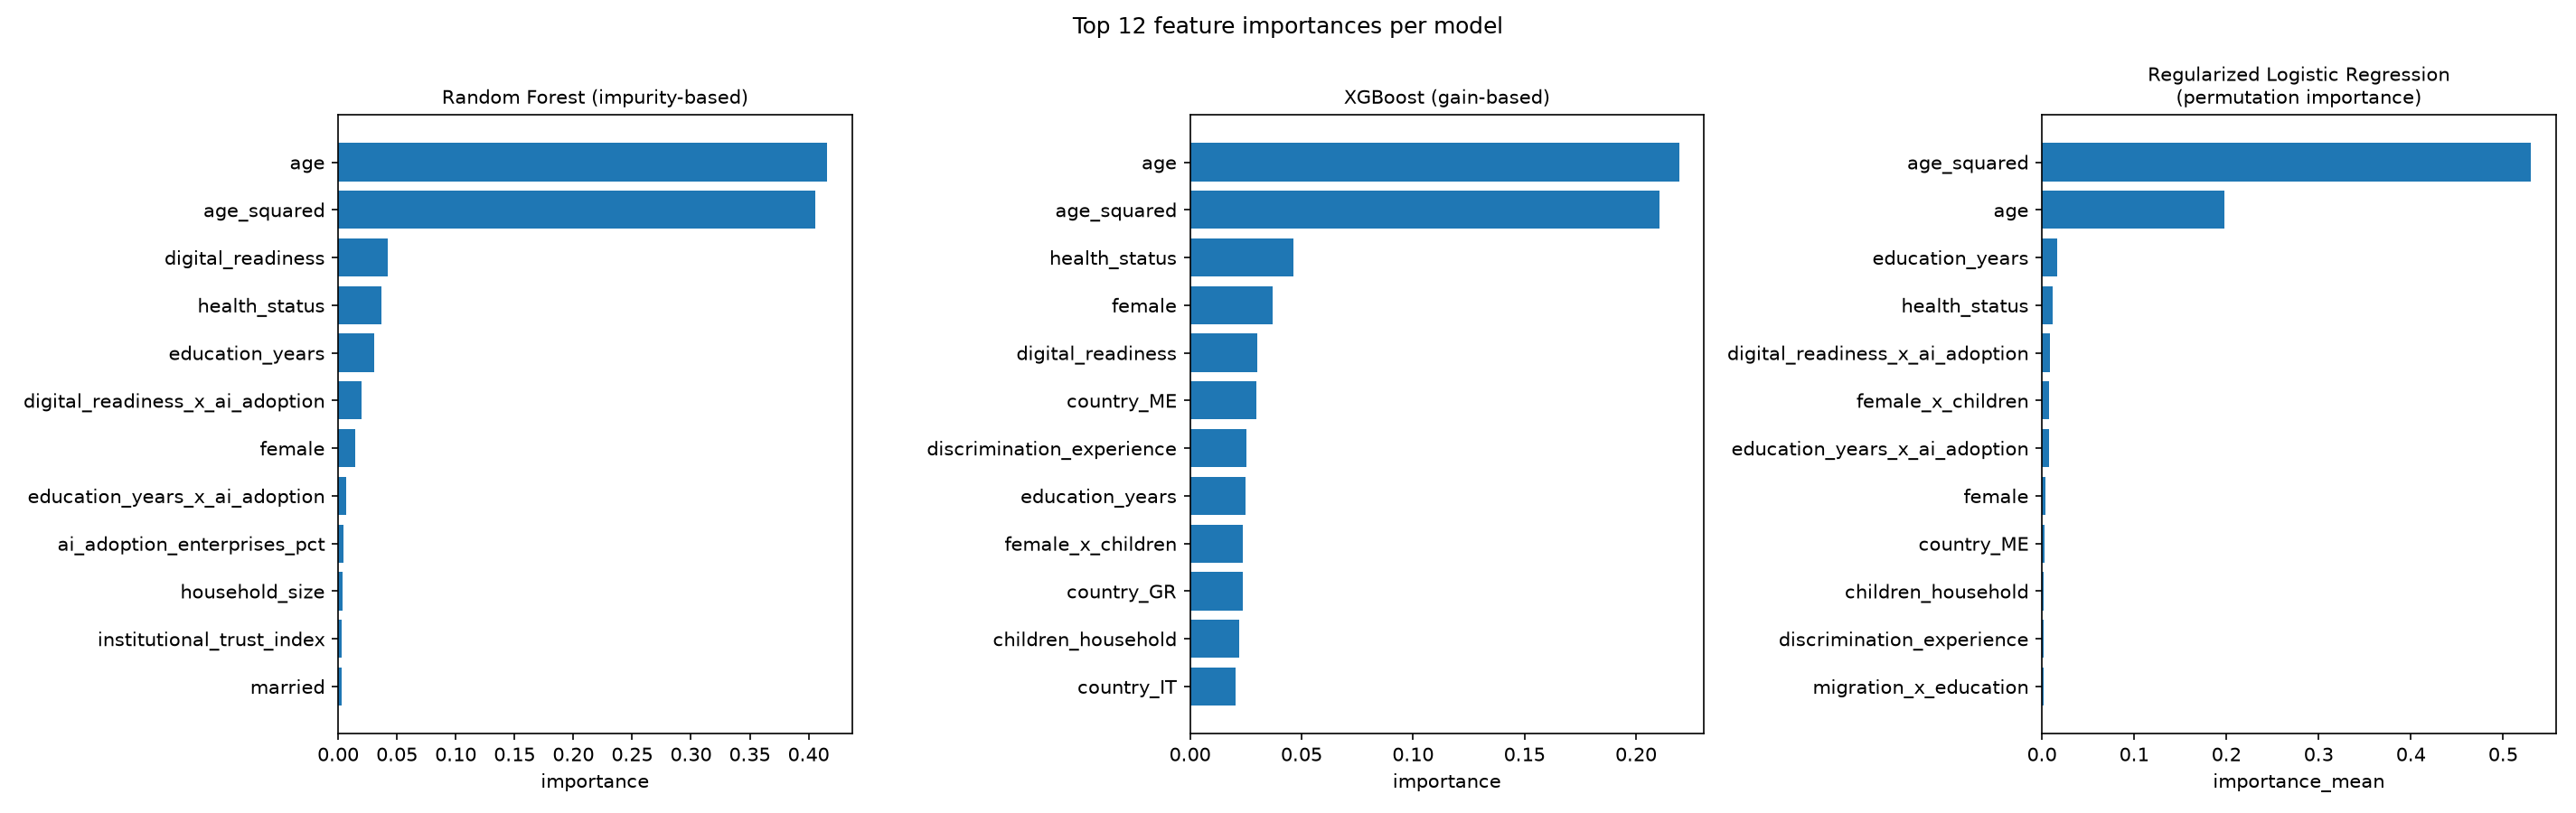

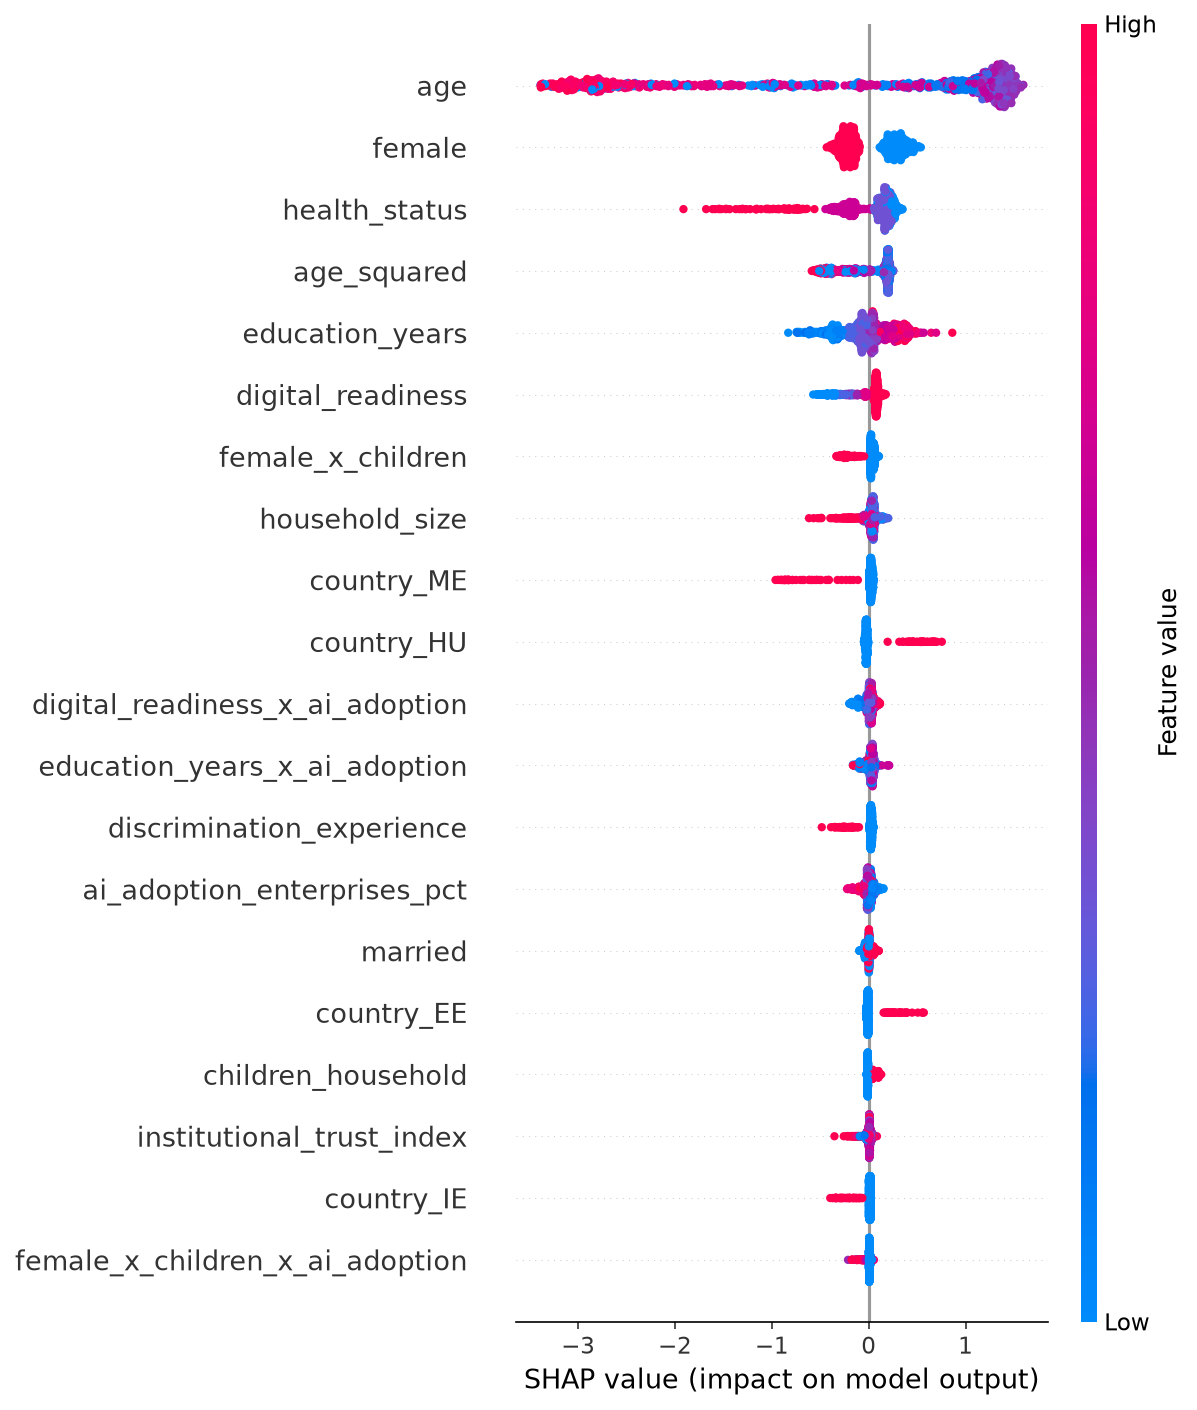

## SHAP

SHAP summary plot computed for XGBoost on a sample of 1000 test rows.

In [18]:
# Reference the existing figures saved by notebook 06 (not regenerated here).
if file_status['ml_feature_importance_png']:
    display(Image(filename=str(REQUIRED_INPUTS['ml_feature_importance_png'])))
else:
    print('MISSING: outputs/figures/ml_feature_importance.png')

if file_status['shap_summary_png']:
    display(Image(filename=str(REQUIRED_INPUTS['shap_summary_png'])))
else:
    print('MISSING: outputs/figures/shap_summary.png')

shap_section = extract_md_section(ml_md_text, '## SHAP')
if shap_section is not None:
    display(Markdown(shap_section))


## 6. Econometrics vs. Machine Learning: Explicit Comparison

Machine learning models above were tuned for **predictive accuracy**, not for
unbiased coefficient estimation or hypothesis testing. Higher ROC AUC for Random
Forest/XGBoost than for the Logistic Regression does **not** mean the tree models are
"more correct" about which variables matter for employment, and it does **not**
validate any causal interpretation of the econometric coefficients in sections 3-4.
The table below states, for the main variable(s) behind each hypothesis, whether the
baseline (notebook 04) and advanced (notebook 05) econometric evidence agree with
each other, and whether machine learning (notebook 06) ranks the same variable as
relatively important for prediction. Agreement across evidence sources strengthens
confidence in a finding; disagreement is reported explicitly, not hidden.


In [19]:
HYPOTHESIS_MAIN_VARS = {
    'H1': ['education_years', 'digital_readiness'],
    'H2': ['ai_adoption_enterprises_pct', 'education_years_x_ai_adoption', 'digital_readiness_x_ai_adoption'],
    'H3': ['female', 'children_household', 'female_x_children', 'female_x_children_x_ai_adoption'],
    'H4': ['migration_background', 'migration_x_education', 'migration_x_digital_readiness'],
    'H5': ['health_status', 'institutional_trust_index', 'discrimination_experience'],
}

if baseline_sheets is None or advanced_sheets is None or ml_sheets is None:
    print('MISSING: one or more of baseline_econometric_results.xlsx, advanced_econometric_results.xlsx, '
          'or ml_model_comparison.xlsx -- cannot build the econometrics-vs-ML comparison table.')
    comparison_rows = []
else:
    baseline_logit = baseline_sheets['model2_logit'].set_index('variable')
    advanced_interaction = advanced_sheets['interaction_model'].set_index('variable')

    # Top-15 important variables per ML model (excluding country dummies).
    top_ml_vars = set()
    for sheet_name, importance_col in [
        ('rf_feature_importance', 'importance'),
        ('xgb_feature_importance', 'importance'),
        ('logreg_permutation_importance', 'importance_mean'),
    ]:
        top = ml_sheets[sheet_name].sort_values(importance_col, ascending=False).head(15)
        top_ml_vars.update(top['variable'].tolist())

    comparison_rows = []
    for h, variables in HYPOTHESIS_MAIN_VARS.items():
        for var in variables:
            base_row = baseline_logit.loc[var] if var in baseline_logit.index else None
            adv_row = advanced_interaction.loc[var] if var in advanced_interaction.index else None

            base_sig = None if base_row is None else bool(base_row['p_value'] < 0.05)
            base_dir = None if base_row is None else ('+' if base_row['coef'] > 0 else '-')
            adv_sig = None if adv_row is None else bool(adv_row['p_value'] < 0.05)
            adv_dir = None if adv_row is None else ('+' if adv_row['coef'] > 0 else '-')

            econ_agrees = (base_dir == adv_dir) if (base_dir is not None and adv_dir is not None) else None
            ml_flags_important = var in top_ml_vars

            comparison_rows.append({
                'hypothesis': h,
                'variable': var,
                'in_baseline_model': base_row is not None,
                'baseline_significant_5pct': base_sig,
                'baseline_direction': base_dir,
                'in_advanced_model': adv_row is not None,
                'advanced_significant_5pct': adv_sig,
                'advanced_direction': adv_dir,
                'baseline_advanced_direction_agree': econ_agrees,
                'ml_top15_importance_any_model': ml_flags_important,
            })

    comparison_df = pd.DataFrame(comparison_rows)
    display(comparison_df)


,hypothesis,variable,in_baseline_model,baseline_significant_5pct,baseline_direction,in_advanced_model,advanced_significant_5pct,advanced_direction,baseline_advanced_direction_agree,ml_top15_importance_any_model
0,H1,education_years,True,True,+,True,True,+,True,True
1,H1,digital_readiness,True,True,+,True,False,+,True,True
2,H2,ai_adoption_enterprises_pct,True,False,+,True,False,-,False,True
3,H2,education_years_x_ai_adoption,False,None,NaN,True,True,-,None,True
4,H2,digital_readiness_x_ai_adoption,False,None,NaN,True,True,+,None,True
5,H3,female,True,True,-,True,True,-,True,True
6,H3,children_household,True,True,-,True,True,+,False,True
7,H3,female_x_children,False,None,NaN,True,True,-,None,True
8,H3,female_x_children_x_ai_adoption,False,None,NaN,True,False,+,None,True
9,H4,migration_background,True,False,-,True,True,+,False,False


## 7. Master Hypothesis Support Table (H1-H5)

Combines the baseline (notebook 04) and advanced (notebook 05) econometric
hypothesis interpretations with the machine learning importance evidence
(notebook 06) into a single table for the thesis Results chapter. The overall
**Status** column takes the more conservative of the two econometric verdicts
(baseline vs. advanced) — a hypothesis is only marked fully "Supported" if both
the baseline and the advanced model support it.


In [20]:
HYPOTHESIS_TITLES = {
    'H1': 'Higher education and stronger digital readiness are associated with higher employment probability.',
    'H2': 'Country-level AI adoption (and its interaction with education/digital readiness) is associated with employment probability.',
    'H3': 'Women and individuals with family responsibilities may have different employment probabilities.',
    'H4': 'Migration background is associated with employment probability, moderated by education and digital readiness.',
    'H5': 'Health, institutional trust, discrimination experience, and unobserved country heterogeneity are relevant employment determinants.',
}

STATUS_ORDER = {'Supported': 2, 'Partially supported': 1, 'Not supported': 0, 'Unclear': -1}


def combine_status(base_status, adv_status):
    if base_status is None or adv_status is None:
        return 'Unclear'
    if base_status == adv_status == 'Supported':
        return 'Supported'
    if base_status == adv_status == 'Not supported':
        return 'Not supported'
    return 'Partially supported'


master_rows = []
for h in ['H1', 'H2', 'H3', 'H4', 'H5']:
    base_block = baseline_hyp_blocks.get(h)
    adv_block = advanced_hyp_blocks.get(h)
    base_status = base_block['status'] if base_block else None
    adv_status = adv_block['status'] if adv_block else None

    ml_note_parts = []
    if ml_sheets is not None:
        for sheet_name, importance_col, model_label in [
            ('rf_feature_importance', 'importance', 'RF'),
            ('xgb_feature_importance', 'importance', 'XGB'),
            ('logreg_permutation_importance', 'importance_mean', 'LogReg'),
        ]:
            grouped = ml_sheets[sheet_name].groupby('hypothesis')[importance_col].sum()
            if h in grouped.index:
                rank = grouped.sort_values(ascending=False).index.get_loc(h) + 1
                ml_note_parts.append(f'{model_label} rank {rank}/{grouped.shape[0]}')
    ml_evidence = '; '.join(ml_note_parts) if ml_note_parts else 'not available'

    overall_conclusion_parts = []
    if base_block:
        overall_conclusion_parts.append(f"Baseline (NB04): {base_block['detail']}")
    if adv_block:
        overall_conclusion_parts.append(f"Advanced (NB05): {adv_block['detail']}")
    overall_conclusion = ' | '.join(overall_conclusion_parts) if overall_conclusion_parts else 'Evidence not available.'

    master_rows.append({
        'Hypothesis': h,
        'Main variables': ', '.join(HYPOTHESIS_MAIN_VARS.get(h, [])),
        'Baseline econometric evidence': base_block['detail'] if base_block else 'not available',
        'Advanced econometric evidence': adv_block['detail'] if adv_block else 'not available',
        'ML evidence': f'Total importance signal grouped by hypothesis -- {ml_evidence}',
        'Overall conclusion': overall_conclusion,
        'Status': combine_status(base_status, adv_status),
    })

master_hypothesis_df = pd.DataFrame(master_rows)
display(master_hypothesis_df)


,Hypothesis,Main variables,Baseline econometric evidence,Advanced econometric evidence,ML evidence,Overall conclusion,Status
0,H1,"education_years, digital_readiness","Supported — education_years (positive, p = 0.0...",Partially supported -- education_years (positi...,Total importance signal grouped by hypothesis ...,Baseline (NB04): Supported — education_years (...,Partially supported
1,H2,"ai_adoption_enterprises_pct, education_years_x...",Not supported — ai_adoption_enterprises_pct (p...,Partially supported -- ai_adoption_enterprises...,Total importance signal grouped by hypothesis ...,Baseline (NB04): Not supported — ai_adoption_e...,Partially supported
2,H3,"female, children_household, female_x_children,...","Supported — female (negative, p = 0.000, sig.)...","Partially supported -- female (negative, p = 0...",Total importance signal grouped by hypothesis ...,"Baseline (NB04): Supported — female (negative,...",Partially supported
3,H4,"migration_background, migration_x_education, m...",Not supported — migration_background (negative...,Partially supported -- migration_background (p...,Total importance signal grouped by hypothesis ...,Baseline (NB04): Not supported — migration_bac...,Partially supported
4,H5,"health_status, institutional_trust_index, disc...","Partially supported — health_status (negative,...",Partially supported -- health_status (negative...,Total importance signal grouped by hypothesis ...,Baseline (NB04): Partially supported — health_...,Partially supported


## 8. Thesis-Ready Tables and Figures

A curated shortlist (not a repeat of every table already produced in notebooks
04-06) of the tables and figures recommended for the thesis Results chapter, with
a one-line caption for each. Existence on disk is checked before listing a file.


In [21]:
thesis_artifacts = [
    ('outputs/tables/baseline_econometric_results.xlsx (sheet: model_comparison)',
     'Model comparison across the four baseline specifications (LPM, Logit, Probit, Logit + country FE).',
     TABLES_DIR / 'baseline_econometric_results.xlsx'),
    ('outputs/tables/advanced_econometric_results.xlsx (sheet: interaction_model)',
     'Main advanced Logit specification with interaction terms (education/digital readiness x AI adoption; gender x children; migration x education/digital readiness).',
     TABLES_DIR / 'advanced_econometric_results.xlsx'),
    ('outputs/tables/vif_results.xlsx (sheet: vif_all)',
     'Multicollinearity (VIF) diagnostics for the baseline and interaction variable sets.',
     TABLES_DIR / 'vif_results.xlsx'),
    ('outputs/figures/marginal_effects_ai_adoption.png',
     'Predicted employment probability across education/digital-readiness levels at low, median, and high country AI adoption.',
     FIGURES_DIR / 'marginal_effects_ai_adoption.png'),
    ('outputs/figures/advanced_econometric_coefficients.png',
     'Coefficient plot for the main advanced Logit (interaction) model.',
     FIGURES_DIR / 'advanced_econometric_coefficients.png'),
    ('outputs/tables/ml_model_comparison.xlsx (sheet: model_comparison)',
     'Predictive performance (accuracy, precision, recall, F1, ROC AUC) of Regularized Logistic Regression, Random Forest, and XGBoost.',
     TABLES_DIR / 'ml_model_comparison.xlsx'),
    ('outputs/figures/ml_feature_importance.png',
     'Random Forest and XGBoost feature importance, grouped by hypothesis.',
     FIGURES_DIR / 'ml_feature_importance.png'),
    ('outputs/figures/shap_summary.png',
     'SHAP summary plot (Random Forest, sample of 1000 test rows) showing direction and magnitude of feature contributions.',
     FIGURES_DIR / 'shap_summary.png'),
]

thesis_artifacts_rows = []
for label, caption, path in thesis_artifacts:
    exists = path.exists()
    thesis_artifacts_rows.append({'artifact': label, 'caption': caption, 'exists_on_disk': exists})
    if not exists:
        print(f'NOTE: {label} does not exist on disk yet ({path}).')

thesis_artifacts_df = pd.DataFrame(thesis_artifacts_rows)
display(thesis_artifacts_df)


,artifact,caption,exists_on_disk
0,outputs/tables/baseline_econometric_results.xl...,Model comparison across the four baseline spec...,True
1,outputs/tables/advanced_econometric_results.xl...,Main advanced Logit specification with interac...,True
2,outputs/tables/vif_results.xlsx (sheet: vif_all),Multicollinearity (VIF) diagnostics for the ba...,True
3,outputs/figures/marginal_effects_ai_adoption.png,Predicted employment probability across educat...,True
4,outputs/figures/advanced_econometric_coefficie...,Coefficient plot for the main advanced Logit (...,True
5,outputs/tables/ml_model_comparison.xlsx (sheet...,"Predictive performance (accuracy, precision, r...",True
6,outputs/figures/ml_feature_importance.png,"Random Forest and XGBoost feature importance, ...",True
7,outputs/figures/shap_summary.png,"SHAP summary plot (Random Forest, sample of 10...",True


## 9. Risks and Limitations

Limitations that apply across notebooks 04-06 and therefore to every result
summarized above. Facts quoted below (sample sizes, cluster counts, VIF flags,
disagreement counts) are pulled directly from the loaded files where available.


In [22]:
limitation_notes = []

limitation_notes.append(
    'Cross-sectional data: ESS Round 11 is a single cross-section, so all associations reported '
    'in this project (and summarized above) describe correlational, not causal, relationships. '
    'No claim in sections 3-7 above should be read as establishing that any variable *causes* '
    'employment.'
)

sample_section = extract_md_section(advanced_md_text, '## Modelling Sample')
if sample_section is not None:
    limitation_notes.append('Modelling sample and listwise deletion (from notebook 05):\n' + sample_section)
else:
    limitation_notes.append('MISSING: could not load the modelling-sample section from advanced_econometric_interpretation.md.')

cluster_section = extract_md_section(advanced_md_text, '## Country-Clustered Standard Errors')
if cluster_section is not None:
    limitation_notes.append('Small number of country clusters (from notebook 05):\n' + cluster_section)

if vif_sheets is not None:
    vif_all_tbl = vif_sheets['vif_all']
    high_vif_vars = sorted(vif_all_tbl.loc[vif_all_tbl['vif'] >= 10, 'variable'].unique().tolist())
    limitation_notes.append(
        'Multicollinearity: the following variables show VIF >= 10 in at least one specification '
        f'in notebook 05 (interaction terms are expected to correlate with their own components): {high_vif_vars}.'
    )

if advanced_sheets is not None:
    wvu = advanced_sheets['weighted_vs_unweighted']
    n_sign_disagree = (~wvu['sign_agrees']).sum()
    n_sig_disagree = (~wvu['significance_agrees_at_5pct']).sum()
    limitation_notes.append(
        f'Survey weighting sensitivity: {n_sign_disagree} of {len(wvu)} coefficients disagree in sign, and '
        f'{n_sig_disagree} of {len(wvu)} disagree in significance at p < 0.05, between the weighted and '
        'unweighted LPM on the same sample (notebook 05) -- conclusions partially change under weighting.'
    )

limitation_notes.append(
    'Proxy variables: children_household and digital_readiness are documented proxies (not direct '
    'measures of childcare responsibility or of individual AI use) -- see docs/variable_dictionary.md.'
)

import re as _re
_ml_dup_m = _re.search(r'features \+ label\):\s*([\d.]+%)', ml_md_text) if ml_md_text else None
_ml_dup_rate = _ml_dup_m.group(1) if _ml_dup_m else 'under 1%'
limitation_notes.append(
    'Tree-model regularization and duplicate check: during notebook 06 development, unconstrained '
    'Random Forest/XGBoost hyperparameters produced a near-perfect (~0.9999) test ROC AUC on the earlier, '
    'much smaller (and, as later established, incorrectly constructed) sample, driven by small groups of '
    'near-identical respondent profiles. On the corrected final feature matrix the measured exact-duplicate '
    f'rate (features + label) is {_ml_dup_rate}, which is not material, so no deduplication was required '
    'before the train/test split. Regularized tree hyperparameters (capped depth, larger minimum '
    'leaf/child-weight sizes) are retained -- see docs/methodology_notes.md and notebook 06 for the '
    'full investigation and the reported duplicate rate.'
)

for i, note in enumerate(limitation_notes, start=1):
    display(Markdown(f'**{i}.** {note}'))


**1.** Cross-sectional data: ESS Round 11 is a single cross-section, so all associations reported in this project (and summarized above) describe correlational, not causal, relationships. No claim in sections 3-7 above should be read as establishing that any variable *causes* employment.

**2.** Modelling sample and listwise deletion (from notebook 05):
## Modelling Sample

- Rows before listwise deletion: 49837
- Rows in main modelling sample: 41265 (8572 dropped due to missing values)
- Base variables used (identical to notebook 04): ['education_years', 'digital_readiness', 'female', 'children_household', 'migration_background', 'health_status', 'age', 'age_squared', 'married', 'household_size', 'institutional_trust_index', 'discrimination_experience', 'ai_adoption_enterprises_pct']
- Interaction terms used: ['education_years_x_ai_adoption', 'digital_readiness_x_ai_adoption', 'female_x_children', 'migration_x_education', 'migration_x_digital_readiness', 'female_x_children_x_ai_adoption']
- Excluded (missing or unavailable): none

**3.** Small number of country clusters (from notebook 05):
## Country-Clustered Standard Errors

Cluster-robust standard errors grouped by country (25 clusters) estimated for the interaction model (Logit). SMALL-CLUSTER CAVEAT: with only 25 clusters, cluster-robust standard error asymptotics are less reliable than with the conventionally recommended 40-50+ clusters; these results should be read as indicative, not definitive, and are reported alongside -- not instead of -- the non-clustered results.

**4.** Multicollinearity: the following variables show VIF >= 10 in at least one specification in notebook 05 (interaction terms are expected to correlate with their own components): ['age', 'age_squared', 'ai_adoption_enterprises_pct', 'digital_readiness_x_ai_adoption', 'education_years_x_ai_adoption', 'migration_background', 'migration_x_digital_readiness', 'migration_x_education'].

**5.** Survey weighting sensitivity: 1 of 20 coefficients disagree in sign, and 3 of 20 disagree in significance at p < 0.05, between the weighted and unweighted LPM on the same sample (notebook 05) -- conclusions partially change under weighting.

**6.** Proxy variables: children_household and digital_readiness are documented proxies (not direct measures of childcare responsibility or of individual AI use) -- see docs/variable_dictionary.md.

**7.** Tree-model regularization and duplicate check: during notebook 06 development, unconstrained Random Forest/XGBoost hyperparameters produced a near-perfect (~0.9999) test ROC AUC on the earlier, much smaller (and, as later established, incorrectly constructed) sample, driven by small groups of near-identical respondent profiles. On the corrected final feature matrix the measured exact-duplicate rate (features + label) is 0.5%, which is not material, so no deduplication was required before the train/test split. Regularized tree hyperparameters (capped depth, larger minimum leaf/child-weight sizes) are retained -- see docs/methodology_notes.md and notebook 06 for the full investigation and the reported duplicate rate.

## 9a. Model Fit Diagnostics Summary

Consolidates the additional model-fit diagnostics added to notebooks 04 and 05
(AIC, BIC, log-likelihood, likelihood-ratio tests, the Hosmer-Lemeshow
goodness-of-fit test, and the multilevel/random-intercept model's variance
component) and the calibration diagnostics added to notebook 06 (Log Loss,
Brier Score) into two compact reference tables for the thesis Results chapter.
All values below are loaded directly from the already-saved outputs of
notebooks 04-06 -- no model is re-estimated here. Where a statistic was not
computed or saved for a given model, the corresponding cell is left blank and
the `note` column states why, rather than inventing a value.

In [23]:
def _sheet(sheets, name):
    return None if sheets is None else sheets.get(name)


fit_diag_04 = _sheet(baseline_sheets, 'model_fit_diagnostics')
lr_null_04 = _sheet(baseline_sheets, 'lr_test_vs_null')
lr_nested_04 = _sheet(baseline_sheets, 'lr_test_nested_block')
hl_summary_04 = _sheet(baseline_sheets, 'hosmer_lemeshow_summary')
model_comp_05 = _sheet(advanced_sheets, 'model_comparison')
lr_int_vs_base_05 = _sheet(advanced_sheets, 'lr_test_interaction_vs_base')
multilevel_var_05 = _sheet(advanced_sheets, 'multilevel_variance_component')

missing_fit_stats = []


def safe_row(df, mask, label):
    """Returns the first matching row of df as a Series, or None (and records why)
    if the sheet or the matching row is not available. Never fabricates a value."""
    if df is None:
        missing_fit_stats.append(f'{label}: source sheet not found.')
        return None
    sub = df.loc[mask(df)]
    if sub.empty:
        missing_fit_stats.append(f'{label}: no matching row found in source sheet.')
        return None
    return sub.iloc[0]


def safe_col(row, col, label):
    if row is None:
        return np.nan
    if col not in row.index:
        missing_fit_stats.append(f'{label}: column "{col}" not found.')
        return np.nan
    return row[col]


# --- Notebook 04: LPM, Logit, Probit, Logit + Country FE ---
row_lpm = safe_row(fit_diag_04, lambda d: d['model_name'] == 'Model 1: LPM (OLS, robust SE)', 'LPM fit diagnostics')
row_logit = safe_row(fit_diag_04, lambda d: d['model_name'] == 'Model 2: Logit (baseline)', 'Logit fit diagnostics')
row_probit = safe_row(fit_diag_04, lambda d: d['model_name'] == 'Model 3: Probit', 'Probit fit diagnostics')
row_fe04 = safe_row(fit_diag_04, lambda d: d['model_name'] == 'Model 4: Logit with country FE', 'Logit+FE (NB04) fit diagnostics')

row_logit_lrnull = safe_row(lr_null_04, lambda d: d['model_name'].str.startswith('Model 2: Logit'), 'Logit vs. null LR test')
row_probit_lrnull = safe_row(lr_null_04, lambda d: d['model_name'].str.startswith('Model 3: Probit'), 'Probit vs. null LR test')
row_fe04_lrnull = safe_row(lr_null_04, lambda d: d['model_name'].str.startswith('Model 4: Logit with country FE'), 'Logit+FE vs. null LR test')
row_nested = safe_row(lr_nested_04, lambda d: d['full_model'] == 'Model 2: Logit (baseline, all variables)', 'Nested-block LR test')
row_hl = safe_row(hl_summary_04, lambda d: pd.Series(True, index=d.index), 'Hosmer-Lemeshow test')

# --- Notebook 05: Interaction model, Interaction + FE model, Multilevel model ---
row_interaction = safe_row(model_comp_05, lambda d: d['model_name'] == 'Interaction model (main)', 'Interaction model AIC/BIC (NB05)')
row_fe_interaction = safe_row(model_comp_05, lambda d: d['model_name'] == 'Country FE + interactions (section 8)', 'Interaction + FE model AIC/BIC (NB05)')
row_lr_int_vs_base = safe_row(lr_int_vs_base_05, lambda d: d['full_model'] == 'Interaction model', 'Interaction vs. base LR test (NB05)')
row_multilevel_var = safe_row(multilevel_var_05, lambda d: d['component'] == 'country (random intercept)', 'Multilevel random-intercept variance (NB05)')

fit_rows = [
    {
        'model': 'LPM (OLS, robust SE)', 'notebook_source': '04',
        'aic': safe_col(row_lpm, 'aic', 'LPM AIC'), 'bic': safe_col(row_lpm, 'bic', 'LPM BIC'),
        'log_likelihood': safe_col(row_lpm, 'log_likelihood', 'LPM log-likelihood'),
        'lr_test_description': None, 'lr_test_statistic': np.nan, 'lr_test_df': np.nan, 'lr_test_p_value': np.nan,
        'hosmer_lemeshow_statistic': np.nan, 'hosmer_lemeshow_df': np.nan, 'hosmer_lemeshow_p_value': np.nan,
        'country_random_intercept_sd': np.nan, 'country_random_intercept_variance': np.nan,
        'note': 'LR test and Hosmer-Lemeshow test are not applicable to a linear probability model; '
                'see the model_fit_diagnostics sheet in notebook 04 for R-squared/Adjusted R-squared instead.',
    },
    {
        'model': 'Logit (baseline)', 'notebook_source': '04',
        'aic': safe_col(row_logit, 'aic', 'Logit AIC'), 'bic': safe_col(row_logit, 'bic', 'Logit BIC'),
        'log_likelihood': safe_col(row_logit, 'log_likelihood', 'Logit log-likelihood'),
        'lr_test_description': 'vs. null (intercept-only) model',
        'lr_test_statistic': safe_col(row_logit_lrnull, 'lr_stat', 'Logit vs. null LR stat'),
        'lr_test_df': safe_col(row_logit_lrnull, 'df', 'Logit vs. null LR df'),
        'lr_test_p_value': safe_col(row_logit_lrnull, 'p_value', 'Logit vs. null LR p-value'),
        'hosmer_lemeshow_statistic': safe_col(row_hl, 'chi_square', 'Hosmer-Lemeshow chi-square'),
        'hosmer_lemeshow_df': safe_col(row_hl, 'df', 'Hosmer-Lemeshow df'),
        'hosmer_lemeshow_p_value': safe_col(row_hl, 'p_value', 'Hosmer-Lemeshow p-value'),
        'country_random_intercept_sd': np.nan, 'country_random_intercept_variance': np.nan,
        'note': '',
    },
    {
        'model': 'Logit (baseline) -- nested-block test', 'notebook_source': '04',
        'aic': np.nan, 'bic': np.nan,
        'log_likelihood': safe_col(row_nested, 'll_restricted', 'Nested-block restricted log-likelihood'),
        'lr_test_description': 'vs. restricted model dropping ai_adoption_enterprises_pct, education_years, '
                                'digital_readiness, female, children_household, migration_background',
        'lr_test_statistic': safe_col(row_nested, 'lr_stat', 'Nested-block LR stat'),
        'lr_test_df': safe_col(row_nested, 'df', 'Nested-block LR df'),
        'lr_test_p_value': safe_col(row_nested, 'p_value', 'Nested-block LR p-value'),
        'hosmer_lemeshow_statistic': np.nan, 'hosmer_lemeshow_df': np.nan, 'hosmer_lemeshow_p_value': np.nan,
        'country_random_intercept_sd': np.nan, 'country_random_intercept_variance': np.nan,
        'note': 'AIC/BIC were not separately computed for this restricted sub-model in notebook 04; only the '
                'restricted log-likelihood and the LR statistic against the full baseline Logit model are available.',
    },
    {
        'model': 'Probit', 'notebook_source': '04',
        'aic': safe_col(row_probit, 'aic', 'Probit AIC'), 'bic': safe_col(row_probit, 'bic', 'Probit BIC'),
        'log_likelihood': safe_col(row_probit, 'log_likelihood', 'Probit log-likelihood'),
        'lr_test_description': 'vs. null (intercept-only) model',
        'lr_test_statistic': safe_col(row_probit_lrnull, 'lr_stat', 'Probit vs. null LR stat'),
        'lr_test_df': safe_col(row_probit_lrnull, 'df', 'Probit vs. null LR df'),
        'lr_test_p_value': safe_col(row_probit_lrnull, 'p_value', 'Probit vs. null LR p-value'),
        'hosmer_lemeshow_statistic': np.nan, 'hosmer_lemeshow_df': np.nan, 'hosmer_lemeshow_p_value': np.nan,
        'country_random_intercept_sd': np.nan, 'country_random_intercept_variance': np.nan,
        'note': 'Hosmer-Lemeshow test was only computed for the baseline Logit model in notebook 04, not for Probit.',
    },
    {
        'model': 'Logit + Country FE', 'notebook_source': '04',
        'aic': safe_col(row_fe04, 'aic', 'Logit+FE (NB04) AIC'), 'bic': safe_col(row_fe04, 'bic', 'Logit+FE (NB04) BIC'),
        'log_likelihood': safe_col(row_fe04, 'log_likelihood', 'Logit+FE (NB04) log-likelihood'),
        'lr_test_description': 'vs. null (intercept-only) model',
        'lr_test_statistic': safe_col(row_fe04_lrnull, 'lr_stat', 'Logit+FE vs. null LR stat'),
        'lr_test_df': safe_col(row_fe04_lrnull, 'df', 'Logit+FE vs. null LR df'),
        'lr_test_p_value': safe_col(row_fe04_lrnull, 'p_value', 'Logit+FE vs. null LR p-value'),
        'hosmer_lemeshow_statistic': np.nan, 'hosmer_lemeshow_df': np.nan, 'hosmer_lemeshow_p_value': np.nan,
        'country_random_intercept_sd': np.nan, 'country_random_intercept_variance': np.nan,
        'note': 'Hosmer-Lemeshow test was only computed for the baseline Logit model in notebook 04, not this '
                'fixed-effects specification.',
    },
    {
        'model': 'Interaction Model', 'notebook_source': '05',
        'aic': safe_col(row_interaction, 'aic', 'Interaction model AIC'), 'bic': safe_col(row_interaction, 'bic', 'Interaction model BIC'),
        'log_likelihood': safe_col(row_lr_int_vs_base, 'll_full', 'Interaction model log-likelihood'),
        'lr_test_description': 'vs. base model (no interaction terms)',
        'lr_test_statistic': safe_col(row_lr_int_vs_base, 'lr_stat', 'Interaction vs. base LR stat'),
        'lr_test_df': safe_col(row_lr_int_vs_base, 'df', 'Interaction vs. base LR df'),
        'lr_test_p_value': safe_col(row_lr_int_vs_base, 'p_value', 'Interaction vs. base LR p-value'),
        'hosmer_lemeshow_statistic': np.nan, 'hosmer_lemeshow_df': np.nan, 'hosmer_lemeshow_p_value': np.nan,
        'country_random_intercept_sd': np.nan, 'country_random_intercept_variance': np.nan,
        'note': 'Hosmer-Lemeshow test was not computed in notebook 05.',
    },
    {
        'model': 'Interaction + FE Model (country FE + interactions)', 'notebook_source': '05',
        'aic': safe_col(row_fe_interaction, 'aic', 'Interaction+FE model AIC'), 'bic': safe_col(row_fe_interaction, 'bic', 'Interaction+FE model BIC'),
        'log_likelihood': np.nan,
        'lr_test_description': None, 'lr_test_statistic': np.nan, 'lr_test_df': np.nan, 'lr_test_p_value': np.nan,
        'hosmer_lemeshow_statistic': np.nan, 'hosmer_lemeshow_df': np.nan, 'hosmer_lemeshow_p_value': np.nan,
        'country_random_intercept_sd': np.nan, 'country_random_intercept_variance': np.nan,
        'note': 'Log-likelihood and a dedicated LR test were not separately saved for this model in notebook 05; '
                'only AIC/BIC are available (advanced_econometric_results.xlsx, model_comparison sheet).',
    },
    {
        'model': 'Multilevel / Random-Intercept Model', 'notebook_source': '05',
        'aic': np.nan, 'bic': np.nan, 'log_likelihood': np.nan,
        'lr_test_description': None, 'lr_test_statistic': np.nan, 'lr_test_df': np.nan, 'lr_test_p_value': np.nan,
        'hosmer_lemeshow_statistic': np.nan, 'hosmer_lemeshow_df': np.nan, 'hosmer_lemeshow_p_value': np.nan,
        'country_random_intercept_sd': safe_col(row_multilevel_var, 'estimated_sd', 'Multilevel country-level SD'),
        'country_random_intercept_variance': safe_col(row_multilevel_var, 'estimated_variance', 'Multilevel country-level variance'),
        'note': 'AIC/BIC, log-likelihood, LR test, and Hosmer-Lemeshow statistic are not computed for this '
                'variational Bayes mixed-effects model in notebook 05; only the random-intercept variance '
                'component is available (multilevel_variance_component sheet).',
    },
]

econometric_fit_diagnostics_table = pd.DataFrame(fit_rows)
econometric_fit_diagnostics_table

,model,notebook_source,aic,bic,log_likelihood,lr_test_description,lr_test_statistic,lr_test_df,lr_test_p_value,hosmer_lemeshow_statistic,hosmer_lemeshow_df,hosmer_lemeshow_p_value,country_random_intercept_sd,country_random_intercept_variance,note
0,"LPM (OLS, robust SE)",04,39440.516062,39561.304841,-19706.258031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LR test and Hosmer-Lemeshow test are not appli...
1,Logit (baseline),04,33376.986043,33497.774822,-16674.493021,vs. null (intercept-only) model,23808.875869,13.0,0.000000e+00,413.184219,8.0,2.829427e-84,NaN,NaN,
2,Logit (baseline) -- nested-block test,04,NaN,NaN,-17259.269868,vs. restricted model dropping ai_adoption_ente...,1169.553694,6.0,1.858138e-249,NaN,NaN,NaN,NaN,NaN,AIC/BIC were not separately computed for this ...
3,Probit,04,33936.082944,34056.871724,-16954.041472,vs. null (intercept-only) model,23249.778967,13.0,0.000000e+00,NaN,NaN,NaN,NaN,NaN,Hosmer-Lemeshow test was only computed for the...
4,Logit + Country FE,04,32887.039643,33206.267132,-16406.519822,vs. null (intercept-only) model,24344.822269,36.0,0.000000e+00,NaN,NaN,NaN,NaN,NaN,Hosmer-Lemeshow test was only computed for the...
5,Interaction Model,05,33184.550000,33357.100000,-16572.273943,vs. base model (no interaction terms),204.438156,6.0,2.154513e-41,NaN,NaN,NaN,NaN,NaN,Hosmer-Lemeshow test was not computed in noteb...
6,Interaction + FE Model (country FE + interacti...,05,32702.080000,33073.070000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Log-likelihood and a dedicated LR test were no...
7,Multilevel / Random-Intercept Model,05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.333472,0.111204,"AIC/BIC, log-likelihood, LR test, and Hosmer-L..."


In [24]:
ml_comp_06 = _sheet(ml_sheets, 'model_comparison')

if ml_comp_06 is None:
    ml_calibration_summary_table = pd.DataFrame()
    print('MISSING: ml_model_comparison.xlsx (model_comparison sheet) -- cannot build the ML calibration summary table.')
else:
    ml_calibration_summary_table = ml_comp_06[['model', 'roc_auc', 'log_loss', 'brier_score']].copy()

ml_calibration_summary_table

,model,roc_auc,log_loss,brier_score
0,Regularized Logistic Regression,0.9012,0.3941,0.1233
1,Random Forest,0.9050,0.3834,0.1202
2,XGBoost,0.9120,0.3708,0.1161


In [25]:
def _fmt_p(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return 'not available'
    return '< 0.001' if p < 0.001 else f'{p:.4g}'

import re as _re
_hl_n_m = _re.search(r'modelling sample:\s*([\d,]+)', advanced_md_text) if advanced_md_text else None
hl_sample_n = int(_hl_n_m.group(1).replace(',', '')) if _hl_n_m else None


aic_ranked = econometric_fit_diagnostics_table.dropna(subset=['aic']).sort_values('aic')
best_model_row = aic_ranked.iloc[0] if not aic_ranked.empty else None

ml_ranked_by_logloss = ml_calibration_summary_table.sort_values('log_loss') if not ml_calibration_summary_table.empty else pd.DataFrame()
ml_ranked_by_auc = ml_calibration_summary_table.sort_values('roc_auc', ascending=False) if not ml_calibration_summary_table.empty else pd.DataFrame()
best_calibrated_ml = ml_ranked_by_logloss.iloc[0] if not ml_ranked_by_logloss.empty else None
best_discriminating_ml = ml_ranked_by_auc.iloc[0] if not ml_ranked_by_auc.empty else None

fit_diagnostics_interpretation_lines = []

if best_model_row is not None:
    fit_diagnostics_interpretation_lines.append(
        f"Among the econometric specifications with AIC/BIC available, **{best_model_row['model']}** "
        f"(notebook {best_model_row['notebook_source']}) shows the lowest AIC ({best_model_row['aic']:,.2f}) "
        f"and BIC ({best_model_row['bic']:,.2f}), indicating the best relative fit among the models compared "
        f"here, ahead of the baseline Logit-with-country-FE specification from notebook 04."
    )

fit_diagnostics_interpretation_lines.append(
    'The likelihood-ratio tests against an intercept-only null model are statistically significant for every '
    'baseline specification tested (Logit, Probit, and Logit with country fixed effects; all p ' + _fmt_p(0) + '), '
    'confirming that the full predictor set jointly improves fit over a null model. The nested-block LR test '
    f"(dropping the AI adoption, education, digital readiness, gender, children, and migration variables) is "
    f"also significant (LR = {row_nested['lr_stat']:.2f}, df = {int(row_nested['df'])}, p " + _fmt_p(row_nested['p_value']) + '), '
    'indicating that this block of variables is jointly associated with employment beyond the remaining controls. '
    f"Similarly, the interaction terms in notebook 05 significantly improve fit over the no-interaction base model "
    f"(LR = {row_lr_int_vs_base['lr_stat']:.2f}, df = {int(row_lr_int_vs_base['df'])}, p = {row_lr_int_vs_base['p_value']:.3g})."
    if (row_nested is not None and row_lr_int_vs_base is not None) else
    'One or more likelihood-ratio test results were not available to summarize here.'
)

if row_hl is not None:
    fit_diagnostics_interpretation_lines.append(
        f"The Hosmer-Lemeshow test for the baseline Logit model rejects the null hypothesis of good fit "
        f"(chi-square = {row_hl['chi_square']:.2f}, df = {int(row_hl['df'])}, p = {row_hl['p_value']:.3g}). "
        + (f'Given the very large sample size (n = {hl_sample_n:,}), ' if hl_sample_n else 'Given the very large sample size, ')
        + 'the Hosmer-Lemeshow test is highly powered and can detect '
        'even small, practically unimportant deviations between predicted and observed employment probabilities '
        'across risk deciles; this result should therefore be interpreted alongside -- not instead of -- the '
        'AIC/BIC and pseudo-R-squared values above, rather than treated as evidence that the model is unusable.'
    )

if row_multilevel_var is not None:
    fit_diagnostics_interpretation_lines.append(
        f"The multilevel (random-intercept) model estimates a country-level standard deviation of "
        f"{row_multilevel_var['estimated_sd']:.4f} (variance = {row_multilevel_var['estimated_variance']:.4f}) "
        'on the standardized-predictor logit scale, indicating that a non-negligible share of variation in the '
        'baseline log-odds of employment is associated with unobserved country-level heterogeneity that remains '
        'after accounting for individual-level predictors. This complements, rather than replaces, the country '
        'fixed-effects specification: the fixed-effects model absorbs country differences as separately '
        'estimated intercepts, while the random-intercept model explicitly characterizes them as a distribution.'
    )

if best_calibrated_ml is not None and best_discriminating_ml is not None:
    consistent = best_calibrated_ml['model'] == best_discriminating_ml['model']
    fit_diagnostics_interpretation_lines.append(
        f"Among the machine learning models, **{best_calibrated_ml['model']}** shows the best calibration "
        f"(lowest Log Loss = {best_calibrated_ml['log_loss']:.4f}, lowest Brier Score = {best_calibrated_ml['brier_score']:.4f}). "
        + ('This is consistent with its ranking on discrimination: it also achieves the highest ROC AUC '
           f"({best_discriminating_ml['roc_auc']:.4f}) among the models compared, so the best-discriminating model "
           'is also the best-calibrated one here.'
           if consistent else
           f"This differs from the ranking on discrimination, where {best_discriminating_ml['model']} achieves the "
           f"highest ROC AUC ({best_discriminating_ml['roc_auc']:.4f}), illustrating that ranking ability and "
           'probability calibration do not always favor the same model.')
    )

fit_diagnostics_interpretation_paragraph = ' '.join(fit_diagnostics_interpretation_lines)
display(Markdown(fit_diagnostics_interpretation_paragraph))

if missing_fit_stats:
    print('\nThe following statistics were not available and were left blank above (not fabricated):')
    for note in missing_fit_stats:
        print(' -', note)
else:
    print('\nAll expected fit-diagnostic sheets/columns for notebooks 04-06 were found.')

Among the econometric specifications with AIC/BIC available, **Interaction + FE Model (country FE + interactions)** (notebook 05) shows the lowest AIC (32,702.08) and BIC (33,073.07), indicating the best relative fit among the models compared here, ahead of the baseline Logit-with-country-FE specification from notebook 04. The likelihood-ratio tests against an intercept-only null model are statistically significant for every baseline specification tested (Logit, Probit, and Logit with country fixed effects; all p < 0.001), confirming that the full predictor set jointly improves fit over a null model. The nested-block LR test (dropping the AI adoption, education, digital readiness, gender, children, and migration variables) is also significant (LR = 1169.55, df = 6, p < 0.001), indicating that this block of variables is jointly associated with employment beyond the remaining controls. Similarly, the interaction terms in notebook 05 significantly improve fit over the no-interaction base model (LR = 204.44, df = 6, p = 2.15e-41). The Hosmer-Lemeshow test for the baseline Logit model rejects the null hypothesis of good fit (chi-square = 413.18, df = 8, p = 2.83e-84). Given the very large sample size (n = 41,265), the Hosmer-Lemeshow test is highly powered and can detect even small, practically unimportant deviations between predicted and observed employment probabilities across risk deciles; this result should therefore be interpreted alongside -- not instead of -- the AIC/BIC and pseudo-R-squared values above, rather than treated as evidence that the model is unusable. The multilevel (random-intercept) model estimates a country-level standard deviation of 0.3335 (variance = 0.1112) on the standardized-predictor logit scale, indicating that a non-negligible share of variation in the baseline log-odds of employment is associated with unobserved country-level heterogeneity that remains after accounting for individual-level predictors. This complements, rather than replaces, the country fixed-effects specification: the fixed-effects model absorbs country differences as separately estimated intercepts, while the random-intercept model explicitly characterizes them as a distribution. Among the machine learning models, **XGBoost** shows the best calibration (lowest Log Loss = 0.3708, lowest Brier Score = 0.1161). This is consistent with its ranking on discrimination: it also achieves the highest ROC AUC (0.9120) among the models compared, so the best-discriminating model is also the best-calibrated one here.


All expected fit-diagnostic sheets/columns for notebooks 04-06 were found.


**Extended Diagnostics: AME, VIF & Calibration**

Adds Average Marginal Effects (AME), fitted-model VIF checks, and the ML ROC/calibration comparison on top of the diagnostics above. Nothing above this point is recomputed or altered.


In [26]:
# --- Extended diagnostics: marginal effects (AME), VIF checks, ROC/calibration ---
# This ADDS to the diagnostics above; nothing above is recomputed or modified. Every
# value below is pulled directly from sheets already saved by notebooks 05 and 06 --
# nothing here is fabricated. If a sheet is missing, this is stated explicitly.

ame_sheet_07 = _sheet(advanced_sheets, 'marginal_effects')
vif_diag_sheet_07 = _sheet(advanced_sheets, 'vif_diagnostics')

extended_diagnostics_missing = []

# --- AME: largest-magnitude variable per model ---
ame_largest_effect_summary = pd.DataFrame()
if ame_sheet_07 is None:
    extended_diagnostics_missing.append('marginal_effects sheet (advanced_econometric_results.xlsx): not found.')
else:
    _ame_rows = []
    for _model_name, _grp in ame_sheet_07.groupby('model', sort=False):
        _grp_nonintercept = _grp.loc[~_grp['variable'].isin(['Intercept', 'const'])]
        if _grp_nonintercept.empty:
            continue
        _top = _grp_nonintercept.loc[_grp_nonintercept['dy/dx'].abs().idxmax()]
        _units = 'per-1-SD (standardized predictor)' if 'Multilevel' in _model_name else 'raw-unit (probability points)'
        _ame_rows.append({
            'model': _model_name,
            'largest_ame_variable': _top['variable'],
            'ame_dy_dx': _top['dy/dx'],
            'units': _units,
        })
    ame_largest_effect_summary = pd.DataFrame(_ame_rows)

print('Largest-magnitude AME variable per model (marginal_effects sheet, advanced_econometric_results.xlsx):')
if ame_largest_effect_summary.empty:
    print('  Not available.')
else:
    for _, r in ame_largest_effect_summary.iterrows():
        print(f"  - {r['model']}: {r['largest_ame_variable']} (dy/dx = {r['ame_dy_dx']:.4f}, {r['units']})")

# --- VIF: high-flag counts per fitted model ---
vif_high_flag_summary = pd.DataFrame()
if vif_diag_sheet_07 is None:
    extended_diagnostics_missing.append('vif_diagnostics sheet (advanced_econometric_results.xlsx): not found.')
else:
    _vif_rows = []
    for _model_name, _grp in vif_diag_sheet_07.groupby('model', sort=False):
        _high = _grp.loc[_grp['flag'] == 'high']
        _high_vars = _high['variable'].tolist()
        _expected_high = [v for v in _high_vars if ('age' in v.lower()) or ('_x_' in v) or v.startswith('C(country')]
        _other_high = [v for v in _high_vars if v not in _expected_high]
        _vif_rows.append({
            'model': _model_name,
            'n_high_vif_vars': len(_high_vars),
            'high_vif_variables': ', '.join(_high_vars) if _high_vars else '(none)',
            'other_high_vif_variables': ', '.join(_other_high) if _other_high else '(none)',
        })
    vif_high_flag_summary = pd.DataFrame(_vif_rows)

print('\nVIF > 10 ("high") flag counts per fitted model (vif_diagnostics sheet, advanced_econometric_results.xlsx):')
if vif_high_flag_summary.empty:
    print('  Not available.')
else:
    for _, r in vif_high_flag_summary.iterrows():
        print(f"  - {r['model']}: {r['n_high_vif_vars']} flagged high -- {r['high_vif_variables']}")
        if r['other_high_vif_variables'] != '(none)':
            print(f"      NOTE: not attributable to the expected age/age_squared quadratic or '_x_' interaction terms: {r['other_high_vif_variables']}")

# --- ML: discrimination (ROC AUC) vs. calibration (Brier score) ---
best_calibrated_ml_brier = (
    ml_calibration_summary_table.sort_values('brier_score').iloc[0]
    if not ml_calibration_summary_table.empty else None
)

print('\nDiscrimination vs. calibration (ml_model_comparison.xlsx, model_comparison sheet;')
print('figures referenced below, NOT regenerated: ml_roc_curves.png, ml_calibration_curve.png):')
if best_discriminating_ml is not None and best_calibrated_ml_brier is not None:
    _same_ml_model = best_discriminating_ml['model'] == best_calibrated_ml_brier['model']
    print(f"  - Best-discriminating (highest ROC AUC): {best_discriminating_ml['model']} (AUC = {best_discriminating_ml['roc_auc']:.4f})")
    print(f"  - Best-calibrated (lowest Brier Score):  {best_calibrated_ml_brier['model']} (Brier = {best_calibrated_ml_brier['brier_score']:.4f})")
    print(f"  - Same model: {_same_ml_model}")
else:
    _same_ml_model = None
    extended_diagnostics_missing.append('ml_model_comparison.xlsx (model_comparison sheet): not found -- cannot compare discrimination vs. calibration.')
    print('  Not available.')

roc_png_path = FIGURES_DIR / 'ml_roc_curves.png'
calibration_png_path = FIGURES_DIR / 'ml_calibration_curve.png'
print(f"\nReferenced figures (not regenerated): {roc_png_path.name} (exists={roc_png_path.exists()}), "
      f"{calibration_png_path.name} (exists={calibration_png_path.exists()})")

if extended_diagnostics_missing:
    print('\nThe following extended-diagnostics inputs were not available and were skipped (not fabricated):')
    for _note in extended_diagnostics_missing:
        print(' -', _note)

display(ame_largest_effect_summary)
display(vif_high_flag_summary)


Largest-magnitude AME variable per model (marginal_effects sheet, advanced_econometric_results.xlsx):
  - Logit (AME): female (dy/dx = -0.0797, raw-unit (probability points))
  - Probit (AME): female (dy/dx = -0.0798, raw-unit (probability points))
  - Interaction model (AME): female_x_children (dy/dx = -0.1249, raw-unit (probability points))
  - Logit + Country FE (AME): female (dy/dx = -0.0816, raw-unit (probability points))
  - Interaction + Country FE (AME): female_x_children (dy/dx = -0.1249, raw-unit (probability points))
  - Multilevel / Random-Intercept (population-averaged FE, approx.): age_squared (dy/dx = -1.4674, per-1-SD (standardized predictor))

VIF > 10 ("high") flag counts per fitted model (vif_diagnostics sheet, advanced_econometric_results.xlsx):
  - Logit + Country FE model: 2 flagged high -- age_squared, age
  - Interaction model (no country FE): 8 flagged high -- age_squared, age, digital_readiness_x_ai_adoption, education_years_x_ai_adoption, ai_adoption_enterpri

,model,largest_ame_variable,ame_dy_dx,units
0,Logit (AME),female,-0.079666,raw-unit (probability points)
1,Probit (AME),female,-0.079843,raw-unit (probability points)
2,Interaction model (AME),female_x_children,-0.124935,raw-unit (probability points)
3,Logit + Country FE (AME),female,-0.081595,raw-unit (probability points)
4,Interaction + Country FE (AME),female_x_children,-0.124918,raw-unit (probability points)
5,Multilevel / Random-Intercept (population-aver...,age_squared,-1.467446,per-1-SD (standardized predictor)


,model,n_high_vif_vars,high_vif_variables,other_high_vif_variables
0,Logit + Country FE model,2,"age_squared, age",(none)
1,Interaction model (no country FE),8,"age_squared, age, digital_readiness_x_ai_adopt...","ai_adoption_enterprises_pct, migration_background"
2,Interaction + Country FE model,7,"age_squared, age, digital_readiness_x_ai_adopt...",migration_background


In [27]:
# --- Build the ONE additional consolidated interpretation paragraph ---
# Association-only language; no causal claims. Appended below the existing
# fit-diagnostics interpretation paragraph, ties AME / VIF / ML calibration
# together with the findings already established above.

_extended_lines = []


def _and_join(items):
    items = list(items)
    if len(items) <= 1:
        return ''.join(items)
    if len(items) == 2:
        return f'{items[0]} and {items[1]}'
    return ', '.join(items[:-1]) + f', and {items[-1]}'


if not ame_largest_effect_summary.empty:
    _ame_bits = '; '.join(
        f"{r['model'].replace(' (AME)', '')}: **{r['largest_ame_variable']}** "
        f"({r['ame_dy_dx']:.3f}, {r['units']})"
        for _, r in ame_largest_effect_summary.iterrows()
    )
    _raw_unit_mask = ame_largest_effect_summary['units'] != 'per-1-SD (standardized predictor)'
    _recurring_counts = ame_largest_effect_summary.loc[_raw_unit_mask, 'largest_ame_variable'].value_counts()
    _recurring_vars = _recurring_counts[_recurring_counts > 1].index.tolist()
    _extended_lines.append(
        'Looking at the Average Marginal Effects now computed for all six econometric specifications, the '
        f"single largest-magnitude effect per model is: {_ame_bits}. Because the Multilevel model's marginal "
        "effects are expressed per 1-SD change in a standardized predictor rather than in raw units, its "
        "largest effect is not directly comparable in size to the raw-unit effects reported for the other "
        "five models"
        + (
            f"; even so, {_and_join(_recurring_vars)} recur"
            f"{'s' if len(_recurring_vars) == 1 else ''} as the single largest-magnitude predictor across "
            "more than one of the raw-unit specifications, echoing the nested-block LR test above, which "
            "already showed this variable block is jointly associated with employment beyond the other controls."
            if _recurring_vars else '.'
        )
    )

if not vif_high_flag_summary.empty:
    _all_other_high = sorted({
        v for _, r in vif_high_flag_summary.iterrows()
        for v in r['other_high_vif_variables'].split(', ') if v != '(none)'
    })
    _extended_lines.append(
        'The fitted-model VIF checks flag a small number of predictors as "high" (VIF > 10) in the interaction '
        'specifications, and these are overwhelmingly the expected age/age_squared quadratic term and the '
        'explicit interaction terms themselves; '
        + (
            f"{_and_join(_all_other_high)} " + ('is' if len(_all_other_high) == 1 else 'are')
            + " also flagged as high VIF in the interaction specifications (entering both as a main effect and "
            "inside one or more interaction terms), which is noted here as a limitation of those specifications "
            "rather than as evidence that any model is misspecified overall -- the Logit + Country FE model "
            "without interaction terms shows only the expected age/age_squared collinearity."
            if _all_other_high else
            'no other variable is flagged as high VIF for reasons unrelated to these expected terms.'
        )
    )

if _same_ml_model is not None:
    if _same_ml_model:
        _extended_lines.append(
            f"Finally, {best_discriminating_ml['model']} is both the best-discriminating "
            f"(AUC = {best_discriminating_ml['roc_auc']:.3f}) and the best-calibrated "
            f"(Brier = {best_calibrated_ml_brier['brier_score']:.3f}) machine learning model here, reinforcing "
            'the fit-diagnostics picture above: the econometric specifications identify which predictors are '
            'associated with employment, while the best machine learning model shows that this same predictor '
            'set also supports strong out-of-sample ranking and reliable predicted probabilities, without '
            'implying any causal interpretation.'
        )
    else:
        _extended_lines.append(
            f"Finally, {best_discriminating_ml['model']} is the best-discriminating machine learning model "
            f"(AUC = {best_discriminating_ml['roc_auc']:.3f}), while {best_calibrated_ml_brier['model']} is the "
            f"best-calibrated one (Brier = {best_calibrated_ml_brier['brier_score']:.3f}), illustrating that "
            'ranking ability and probability calibration do not always favor the same model; either way, this '
            'complements rather than contradicts the econometric fit-diagnostics picture above, without '
            'implying any causal interpretation.'
        )

extended_diagnostics_paragraph = ' '.join(_extended_lines)
display(Markdown(extended_diagnostics_paragraph))


Looking at the Average Marginal Effects now computed for all six econometric specifications, the single largest-magnitude effect per model is: Logit: **female** (-0.080, raw-unit (probability points)); Probit: **female** (-0.080, raw-unit (probability points)); Interaction model: **female_x_children** (-0.125, raw-unit (probability points)); Logit + Country FE: **female** (-0.082, raw-unit (probability points)); Interaction + Country FE: **female_x_children** (-0.125, raw-unit (probability points)); Multilevel / Random-Intercept (population-averaged FE, approx.): **age_squared** (-1.467, per-1-SD (standardized predictor)). Because the Multilevel model's marginal effects are expressed per 1-SD change in a standardized predictor rather than in raw units, its largest effect is not directly comparable in size to the raw-unit effects reported for the other five models; even so, female and female_x_children recur as the single largest-magnitude predictor across more than one of the raw-unit specifications, echoing the nested-block LR test above, which already showed this variable block is jointly associated with employment beyond the other controls. The fitted-model VIF checks flag a small number of predictors as "high" (VIF > 10) in the interaction specifications, and these are overwhelmingly the expected age/age_squared quadratic term and the explicit interaction terms themselves; ai_adoption_enterprises_pct and migration_background are also flagged as high VIF in the interaction specifications (entering both as a main effect and inside one or more interaction terms), which is noted here as a limitation of those specifications rather than as evidence that any model is misspecified overall -- the Logit + Country FE model without interaction terms shows only the expected age/age_squared collinearity. Finally, XGBoost is both the best-discriminating (AUC = 0.912) and the best-calibrated (Brier = 0.116) machine learning model here, reinforcing the fit-diagnostics picture above: the econometric specifications identify which predictors are associated with employment, while the best machine learning model shows that this same predictor set also supports strong out-of-sample ranking and reliable predicted probabilities, without implying any causal interpretation.

## 10. Save Final Outputs

Saves the two final deliverables for the thesis Results chapter:
- `outputs/tables/final_hypothesis_summary.xlsx`
- `outputs/reports/final_results_summary.md`


In [28]:
TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

final_xlsx_path = TABLES_DIR / 'final_hypothesis_summary.xlsx'
with pd.ExcelWriter(final_xlsx_path, engine='openpyxl') as writer:
    master_hypothesis_df.to_excel(writer, sheet_name='hypothesis_summary', index=False)
    if baseline_sheets is not None:
        baseline_sheets['model_comparison'].to_excel(writer, sheet_name='baseline_model_comparison', index=False)
    if advanced_sheets is not None:
        advanced_sheets['model_comparison'].to_excel(writer, sheet_name='advanced_model_comparison', index=False)
    if ml_sheets is not None:
        ml_sheets['model_comparison'].to_excel(writer, sheet_name='ml_model_comparison', index=False)
    if comparison_rows:
        comparison_df.to_excel(writer, sheet_name='econometrics_vs_ml', index=False)
    thesis_artifacts_df.to_excel(writer, sheet_name='thesis_tables_figures', index=False)
    status_df.to_excel(writer, sheet_name='input_file_status', index=False)
    econometric_fit_diagnostics_table.to_excel(writer, sheet_name='model_fit_diagnostics', index=False, startrow=0)
    if not ml_calibration_summary_table.empty:
        _mfd_ws = writer.sheets['model_fit_diagnostics']
        _mfd_next_row = len(econometric_fit_diagnostics_table) + 3
        _mfd_ws.cell(row=_mfd_next_row, column=1, value='ML Model Calibration Summary (Notebook 06)')
        ml_calibration_summary_table.to_excel(writer, sheet_name='model_fit_diagnostics', index=False, startrow=_mfd_next_row + 1)

    # --- Extended diagnostics: AME + VIF summary blocks (additive, stacked below
    # the tables above in the same sheet; the two tables above are untouched). ---
    _ext_row_cursor = len(econometric_fit_diagnostics_table) + 3
    if not ml_calibration_summary_table.empty:
        _ext_row_cursor += 1 + len(ml_calibration_summary_table) + 2
    if not ame_largest_effect_summary.empty:
        _mfd_ws2 = writer.sheets['model_fit_diagnostics']
        _mfd_ws2.cell(row=_ext_row_cursor, column=1, value='Largest-Magnitude AME per Model (Notebooks 04-05)')
        ame_largest_effect_summary.to_excel(writer, sheet_name='model_fit_diagnostics', index=False, startrow=_ext_row_cursor + 1)
        _ext_row_cursor += len(ame_largest_effect_summary) + 4
    if not vif_high_flag_summary.empty:
        _mfd_ws2 = writer.sheets['model_fit_diagnostics']
        _mfd_ws2.cell(row=_ext_row_cursor, column=1, value='VIF High-Flag Counts per Fitted Model (Notebook 05)')
        vif_high_flag_summary.to_excel(writer, sheet_name='model_fit_diagnostics', index=False, startrow=_ext_row_cursor + 1)

print(f'Saved: {final_xlsx_path} ({final_xlsx_path.stat().st_size} bytes)')


Saved: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\tables\final_hypothesis_summary.xlsx (16039 bytes)


In [29]:
report_lines = []
report_lines.append('# Final Results Summary\n')
report_lines.append(
    'Generated by notebooks/07_model_comparison_and_results.ipynb. This report combines the '
    'already-saved results of notebooks 04-06 -- no new model was fit to produce it. All '
    'statements use association language only.\n'
)

report_lines.append('## Master Hypothesis Support Table (H1-H5)\n')
report_lines.append(master_hypothesis_df.to_markdown(index=False) + '\n')

report_lines.append('## Econometrics vs. Machine Learning Comparison\n')
if comparison_rows:
    report_lines.append(comparison_df.to_markdown(index=False) + '\n')
else:
    report_lines.append('Not available -- one or more required input files were missing.\n')

report_lines.append('## Thesis-Ready Tables and Figures\n')
report_lines.append(thesis_artifacts_df.to_markdown(index=False) + '\n')

report_lines.append('## Risks and Limitations\n')
for i, note in enumerate(limitation_notes, start=1):
    report_lines.append(f'{i}. {note}\n')

report_lines.append('## Input File Status\n')
report_lines.append(status_df.to_markdown(index=False) + '\n')

report_lines.append('## Model Fit Diagnostics Summary\n')
report_lines.append(econometric_fit_diagnostics_table.to_markdown(index=False) + '\n')
report_lines.append('ML Model Calibration Summary (Notebook 06):\n')
report_lines.append(
    (ml_calibration_summary_table.to_markdown(index=False) if not ml_calibration_summary_table.empty
     else 'Not available -- ml_model_comparison.xlsx (model_comparison sheet) was not found.') + '\n'
)
report_lines.append(fit_diagnostics_interpretation_paragraph + '\n')

report_lines.append('\n**Extended Diagnostics: AME, VIF & Calibration**\n')
if not ame_largest_effect_summary.empty:
    report_lines.append('Largest-magnitude AME variable per model (marginal_effects sheet):\n')
    report_lines.append(ame_largest_effect_summary.to_markdown(index=False) + '\n')
if not vif_high_flag_summary.empty:
    report_lines.append('VIF > 10 ("high") flag counts per fitted model (vif_diagnostics sheet):\n')
    report_lines.append(vif_high_flag_summary.to_markdown(index=False) + '\n')
report_lines.append(extended_diagnostics_paragraph + '\n')

final_md_path = REPORTS_DIR / 'final_results_summary.md'
final_md_path.write_text('\n'.join(report_lines), encoding='utf-8')
print(f'Saved: {final_md_path} ({final_md_path.stat().st_size} bytes)')


Saved: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\reports\final_results_summary.md (35423 bytes)
